In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib_venn import venn2, venn3, venn3_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.42 GB, difference +2.42 GB
CPU times: user 559 ms, sys: 1.71 s, total: 2.27 s
Wall time: 5.45 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [3]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 1.8 s, sys: 1.45 s, total: 3.25 s
Wall time: 3.28 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


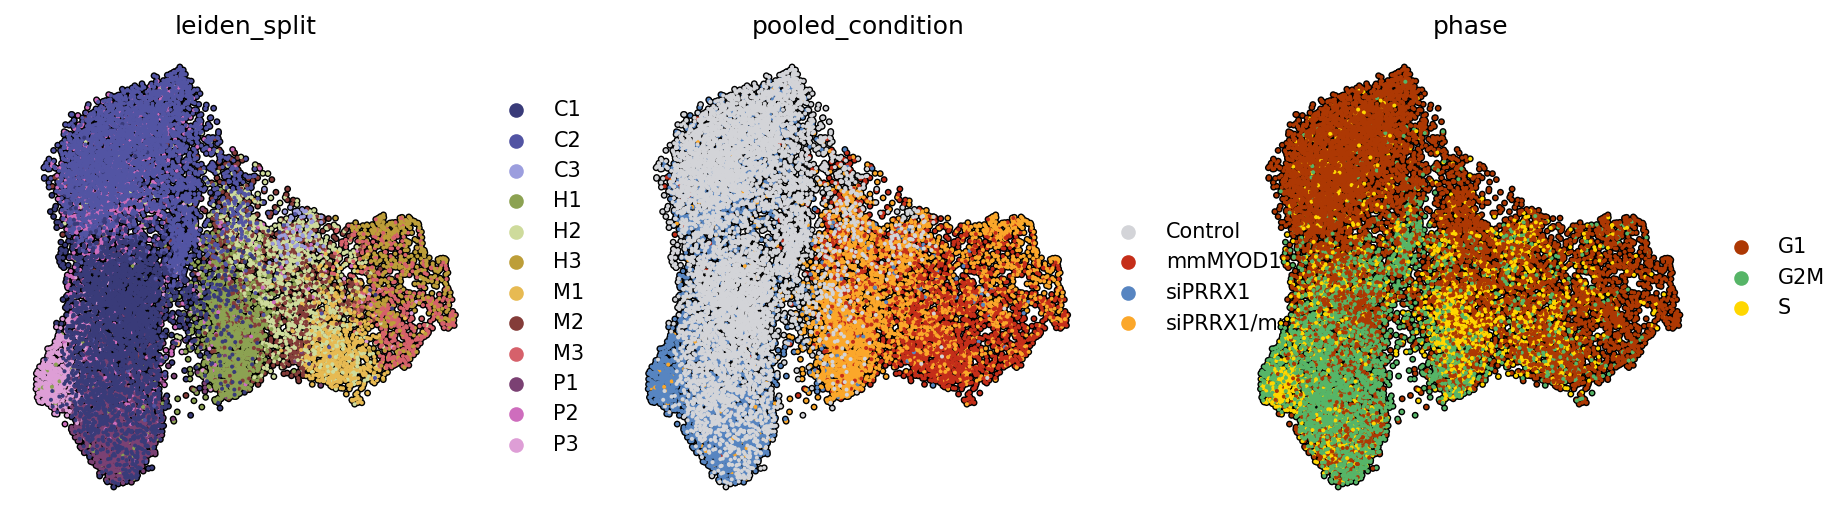

In [4]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['leiden_split', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Get cell cycle genes

In [4]:
# # GO cell cycle genes
# fpath = "../../resources/human_cell_cycle_genes.csv"
# cdf = pd.read_csv(fpath)
# go_cc_genes = cdf['gene_name'].unique()
# print(f"N unique GO cell cycle genes: {cdf['gene_name'].nunique()}")

# # Regev cell cycle genes
# fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
# regev_genes = [x.strip() for x in open(fpath)]
# s_genes = regev_genes[:43]
# g2m_genes = regev_genes[43:]


# cc_genes = list(set(go_cc_genes) | set(regev_genes))
# print(len(cc_genes))

N unique GO cell cycle genes: 142
235


In [5]:
# phase_map = {
#     'G1': 'G1 Phase',
#     'G1/S_transition': 'G1/S Transition Checkpoint Signaling',
#     'S': 'S Phase',
#     'G2': 'G2 Phase',
#     'G2/M_transition': 'G2/M Transition Checkpoint Signaling',
#     'M': 'M Phase',
# }

# cc_dict = {
#     short_name: cdf.loc[cdf[col_name] == True, 'gene_name'].tolist()
#     for short_name, col_name in phase_map.items()
# }

# for gene in s_genes:
#     if gene not in cc_dict["S"]:
#         cc_dict["S"].append(gene)

# cc_dict["G2M"] = list(g2m_genes)

# # Remove unique G2 and M keys, add to G2M key
# for gene in cc_dict.get("G2", []) + cc_dict.get("M", []):
#     if gene not in cc_dict["G2M"]:
#         cc_dict["G2M"].append(gene)
        
        
# cc_dict.pop("G2", None)
# cc_dict.pop("M", None)

['CNOT6', 'CSDE1', 'DRD2', 'DRD3', 'DRD4', 'HBS1L', 'PELO']

In [6]:
# cc_dict.keys()

dict_keys(['G1', 'G1/S_transition', 'S', 'G2/M_transition', 'G2M'])

## Update cc_genes

In [5]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [6]:
cc_cols_to_keep = [
    # G1/S transition
    'G1/S Transition of Mitotic Cell Cycle (GO:0000082)',
    # 'Cell Cycle G1/S Phase Transition (GO:0044843)',
    # 'Regulation of Cell Cycle G1/S Phase Transition (GO:1902806)',
    'Regulation of G1/S Transition of Mitotic Cell Cycle (GO:2000045)',

    # G2/M transition
    'G2/M Transition of Mitotic Cell Cycle (GO:0000086)',
    # 'Cell Cycle G2/M Phase Transition (GO:0044839)',
    # 'Regulation of Cell Cycle G2/M Phase Transition (GO:1902749)',
    'Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010389)',

    # Checkpoints
    'Mitotic G1/S Transition Checkpoint Signaling (GO:0044819)',
    'Mitotic G2/M Transition Checkpoint (GO:0044818)',
    # 'Regulation of G0 to G1 Transition (GO:0070316)',
]

geneset_filt = geneset[cc_cols_to_keep]
print(geneset_filt.shape)
geneset_filt.head()

geneset_filt = geneset_filt.melt(value_name='gene_name', var_name='GO_term')
geneset_filt = geneset_filt.dropna(subset=['gene_name'])

geneset_filt["transition"] = geneset_filt["GO_term"].apply(
    lambda x: "G1S_transition" if "G1/S" in x else 
              ("G2M_transition" if "G2/M" in x else None)
)

cell_cycle_df = (
    geneset_filt
    .assign(value=True)
    .pivot_table(index="gene_name", columns="transition", values="value", aggfunc='any', fill_value=False).astype(bool)
)

cell_cycle_df = cell_cycle_df.reset_index()
cell_cycle_df.columns.name = None
print(cell_cycle_df.shape)
cell_cycle_df.head()


# GO cell cycle genes from Cooper
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
print(cdf.shape)
cdf.head()

# Merge into 1 GO df
merge_cdf = cell_cycle_df.merge(cdf, how='outer', on='gene_name')
print(merge_cdf.shape)
merge_cdf.head()


# Add regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
regev_genes = [x.strip() for x in open(fpath)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]


def add_missing_genes(df, gene_dict, gene_col='gene_name'):
    result = df.copy()
    for target_col, gene_list in gene_dict.items():
        for gene in gene_list:
            if gene in set(result[gene_col]):
                # Update existing row(s) → force target_col to True
                result.loc[result[gene_col] == gene, target_col] = True
            else:
                # Create a new row with all False except target_col
                new_row = {col: False for col in result.columns if col != gene_col}
                new_row[target_col] = True
                new_row[gene_col] = gene
                result = pd.concat([result, pd.DataFrame([new_row])], ignore_index=True)

    return result


cdf_final = add_missing_genes(
    merge_cdf,
    {'S Phase': s_genes, 'G2 Phase': g2m_genes},
)

print(cdf_final.shape)
cdf_final.head()

(2250, 6)
(270, 3)
(142, 7)
(325, 9)
(409, 9)


,gene_name,G1S_transition,G2M_transition,G1 Phase,G1/S Transition Checkpoint Signaling,G2 Phase,G2/M Transition Checkpoint Signaling,M Phase,S Phase
0,ABCB1,NaN,NaN,False,False,False,True,False,False
1,ACTL6B,True,False,NaN,NaN,NaN,NaN,NaN,NaN
2,ACVR1,True,False,NaN,NaN,NaN,NaN,NaN,NaN
3,ACVR1B,NaN,NaN,False,True,False,False,False,False
4,ADAM17,True,False,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# extract list of all cell cycle genes
cc_genes = cdf_final['gene_name'].unique()
cc_genes = [g for g in cc_genes if g in adata.var_names]
print(f"N cell cycle genes: {len(cc_genes)}")


# get just G1/S genes
G1S_genes = []

for phase in ['G1 Phase', 'G1S_transition', 'S Phase']:
    genes_in_col = cdf_final.loc[cdf_final[phase].astype(bool), 'gene_name'].tolist()
    G1S_genes.extend(genes_in_col)

G1S_genes = list(set(G1S_genes)) # keep only unique genes
G1S_genes = [g for g in G1S_genes if g in adata.var_names]
print(f"N G1/S phase genes: {len(G1S_genes)}")
    
# get just G2/M genes
G2M_genes = []

for phase in ['G2 Phase', 'G2M_transition', 'M Phase']:
    genes_in_col = cdf_final.loc[cdf_final[phase].astype(bool), 'gene_name'].tolist()
    G2M_genes.extend(genes_in_col)

G2M_genes = list(set(G2M_genes)) # keep only unique genes
G2M_genes = [g for g in G2M_genes if g in adata.var_names]
print(f"N G2/M phase genes: {len(G2M_genes)}")

N cell cycle genes: 374
N G1/S phase genes: 299
N G2/M phase genes: 300


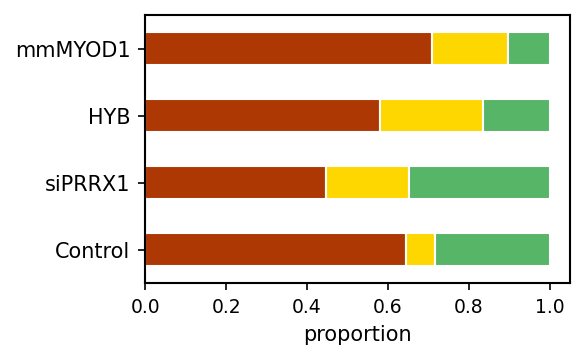

In [8]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2.5

counts = adata.obs.groupby(['pooled_condition', 'phase'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase', values='count').fillna(0)

col_order = ['G1', 'S', 'G2M']
row_order = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']

pivot_counts = pivot_counts[col_order]
pivot_counts = pivot_counts.reindex(row_order)

df_prop = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)
colors = ['#ad3803', 'gold', '#56b567']

df_prop.plot(
    kind='barh',
    stacked=True,
    color=colors,
    legend=False,
    ec='white',
    width=0.5,
)

# tick_labels = ['+MYOD1', r'PRRX1$^{\mathrm{KD}}$+MYOD1', r'PRRX1$^{\mathrm{KD}}$', 'Control']
# tick_labels = ['Control', r'PRRX1$^{\mathrm{KD}}$', r'PRRX1$^{\mathrm{KD}}$+MYOD1', '+MYOD1']
tick_labels = ['Control', 'siPRRX1', 'HYB', 'mmMYOD1']
plt.ylabel("")
plt.yticks(ticks=range(len(row_order)), labels=tick_labels)

plt.xlabel("proportion")
plt.xticks(fontsize=9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.01) 
    
plt.tight_layout()
plt.show()

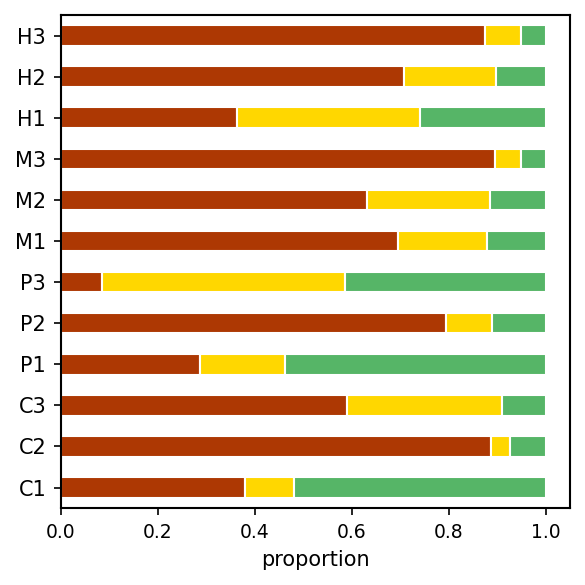

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

counts = adata.obs.groupby(['leiden_split', 'phase'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='leiden_split', columns='phase', values='count').fillna(0)

col_order = ['G1', 'S', 'G2M']
row_order = ['C1','C2', 'C3', 'P1', 'P2', 'P3', 'M1', 'M2', 'M3', 'H1', 'H2', 'H3']

pivot_counts = pivot_counts[col_order]
pivot_counts = pivot_counts.reindex(row_order)

df_prop = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)
colors = ['#ad3803', 'gold', '#56b567']

df_prop.plot(
    kind='barh',
    stacked=True,
    color=colors,
    legend=False,
    ec='white',
    width=0.5,
)

# tick_labels = ['+MYOD1', r'PRRX1$^{\mathrm{KD}}$+MYOD1', r'PRRX1$^{\mathrm{KD}}$', 'Control']
# tick_labels = ['Control', r'PRRX1$^{\mathrm{KD}}$', r'PRRX1$^{\mathrm{KD}}$+MYOD1', '+MYOD1']
# tick_labels = ['Control', 'siPRRX1', 'HYB', 'mmMYOD1']
plt.ylabel("")
# plt.yticks(ticks=range(len(row_order)), labels=tick_labels)

plt.xlabel("proportion")
plt.xticks(fontsize=9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.01) 
    
plt.tight_layout()
plt.show()

# Group cells by condition and phase

In [10]:
phase_group_map = {
    "G1": "G1S",
    "S": "G1S",
    "G2M": "G2M"
}

adata.obs["condition_by_phase_group"] = (
    adata.obs["pooled_condition"].astype(str) + "_" +
    adata.obs["phase"].map(phase_group_map)
)

# Make categorical and optionally order
conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phase_groups = ["G1S", "G2M"]
ordered_categories = [f"{cond}_{ph}" for ph in phase_groups for cond in conditions]

adata.obs["condition_by_phase_group"] = pd.Categorical(
    adata.obs["condition_by_phase_group"],
    categories=ordered_categories,
    ordered=True
)

adata.obs["condition_by_phase_group"].value_counts(sort=False)

condition_by_phase_group
Control_G1S            4944
mmMYOD1_G1S            2022
siPRRX1_G1S            2402
siPRRX1/mmMYOD1_G1S    2885
Control_G2M            1958
mmMYOD1_G2M             233
siPRRX1_G2M            1281
siPRRX1/mmMYOD1_G2M     571
Name: count, dtype: int64

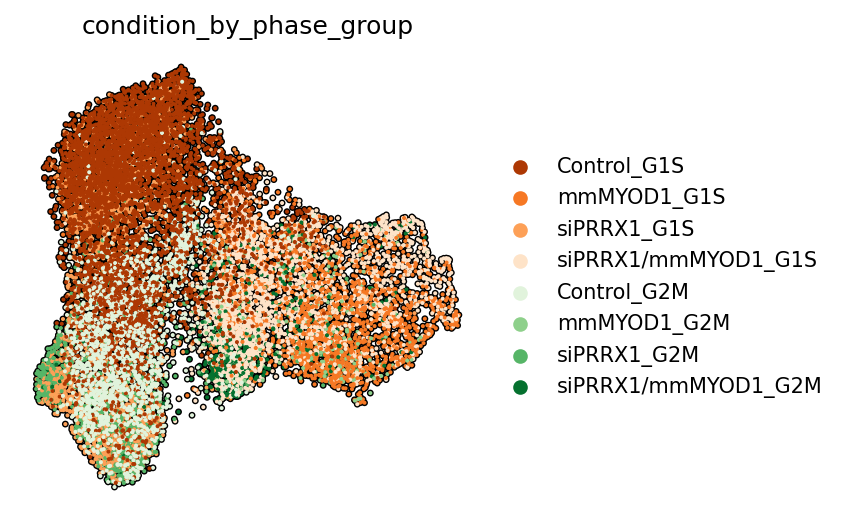

In [11]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

phase_group_colors = [
    # G1/S - Oranges
    '#ad3803',
    '#f67824',
    '#fda057',
    '#fee3c8',
    # G2/M - Greens
    '#e1f3dc',
    '#8ed08b',
    '#56b567',
    '#05712f',
]
    

sc.pl.umap(
    adata,
    color=['condition_by_phase_group'],
    size=15,
    add_outline=True,
    palette=phase_group_colors,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

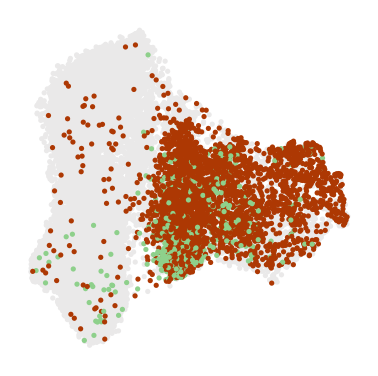

In [12]:
mask_prrx = adata.obs['pooled_condition'] == 'siPRRX1'
mask_myod = adata.obs['pooled_condition'] == 'mmMYOD1'
mask_hyb = adata.obs['pooled_condition'] == 'siPRRX1/mmMYOD1'
mask_ctrl = adata.obs['pooled_condition'] == 'Control'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

colors = ['#ad3803'] * 4 + ['#8ed08b'] * 4


sc.pl.umap(
    adata,
    color='condition_by_phase_group',
    mask_obs=mask_hyb,
    size=25,
    frameon=False,
    alpha=1,
    na_color='#EAE9E9',
    title='',
    legend_loc='none',
    palette=colors,
    # legend_loc='on data',
    # na_in_legend=False,
    # legend_fontoutline=2,
    # legend_fontsize='medium',
)

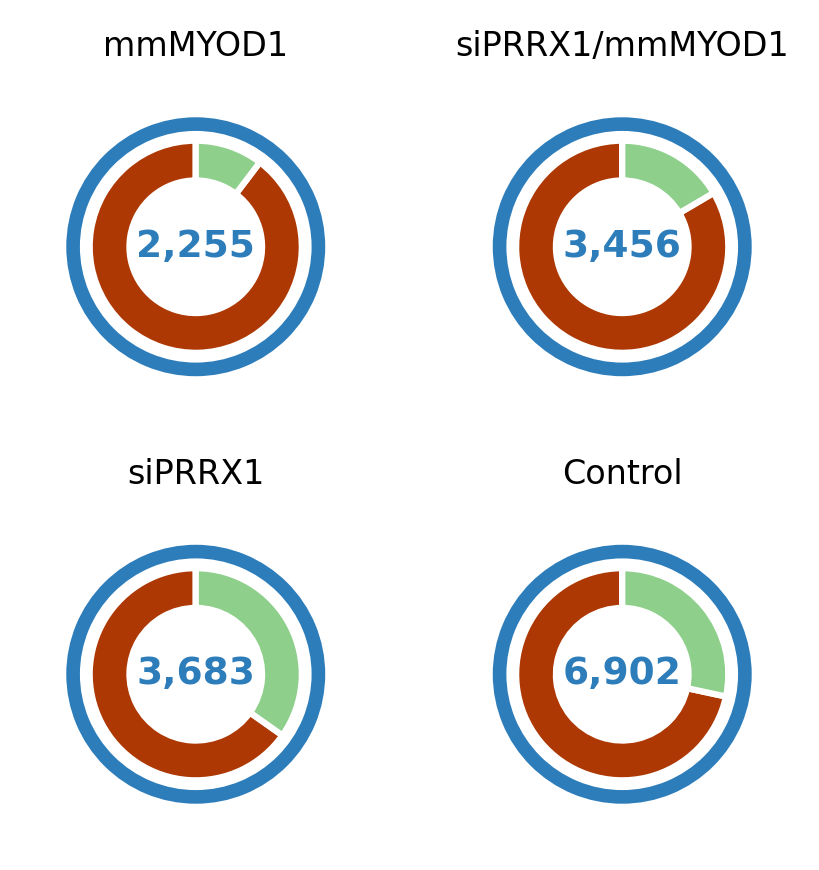

In [12]:
phase_group_map = {
    "G1": "G1S",
    "S": "G1S",
    "G2M": "G2M"
}

adata.obs["phase_grouped"] = (
    adata.obs["phase"].map(phase_group_map)
)


counts = adata.obs.groupby(['pooled_condition', 'phase_grouped'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase_grouped', values='count').fillna(0)

pivot_counts.head()


color_map = {
    "G1S": '#ad3803',
    "G2M": '#8ed08b',#'#56b567',
}

# clusters = pivot_counts.index.tolist()
clusters = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control']

plt.rcParams['figure.figsize'] = 3, 3#6, 2
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

# Donut plots
for i, cluster in enumerate(clusters):
    ax = axes[i]
    data = pivot_counts.loc[cluster]
    colors = [color_map[cond] for cond in data.index]

    ax.pie(
        [1],   # single slice = all cells
        radius=1.0,
        colors=['#2D7DBB'],  # blue
        startangle=90,
        wedgeprops=dict(width=0.15, edgecolor='white', linewidth=1.5)
    )
    
    ax.pie(
        data,
        labels=None,
        startangle=90,
        colors=colors,
        wedgeprops=dict(linewidth=1.5, edgecolor='white', width=0.3, radius=0.8)
    )
    
    total_cells = int(data.sum())
    
    ax.text(
        0, 0,  # center of the pie
        f"{total_cells:,}",
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#2D7DBB',
    )
    
    # wedges, label = ax.pie(
    #     data,
    #     labels=None,
    #     startangle=90,
    #     colors=colors,
    #     wedgeprops=dict(linewidth=1, edgecolor='white', width=0.35),
    # )
    
    ax.set(aspect='equal')
    ax.set_title(f"{cluster}", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

In [13]:
pivot_counts['pct_g1s'] = pivot_counts['G1S'] / pivot_counts.sum(axis=1)
pivot_counts['pct_g2m'] = 1 - pivot_counts['pct_g1s']
pivot_counts['total_cells'] = pivot_counts['G1S'] + pivot_counts['G2M']
pivot_counts

phase_grouped,G1S,G2M,pct_g1s,pct_g2m,total_cells
pooled_condition,,,,,
Control,4944,1958,0.716314,0.283686,6902
mmMYOD1,2022,233,0.896674,0.103326,2255
siPRRX1,2402,1281,0.652186,0.347814,3683
siPRRX1/mmMYOD1,2885,571,0.834780,0.165220,3456


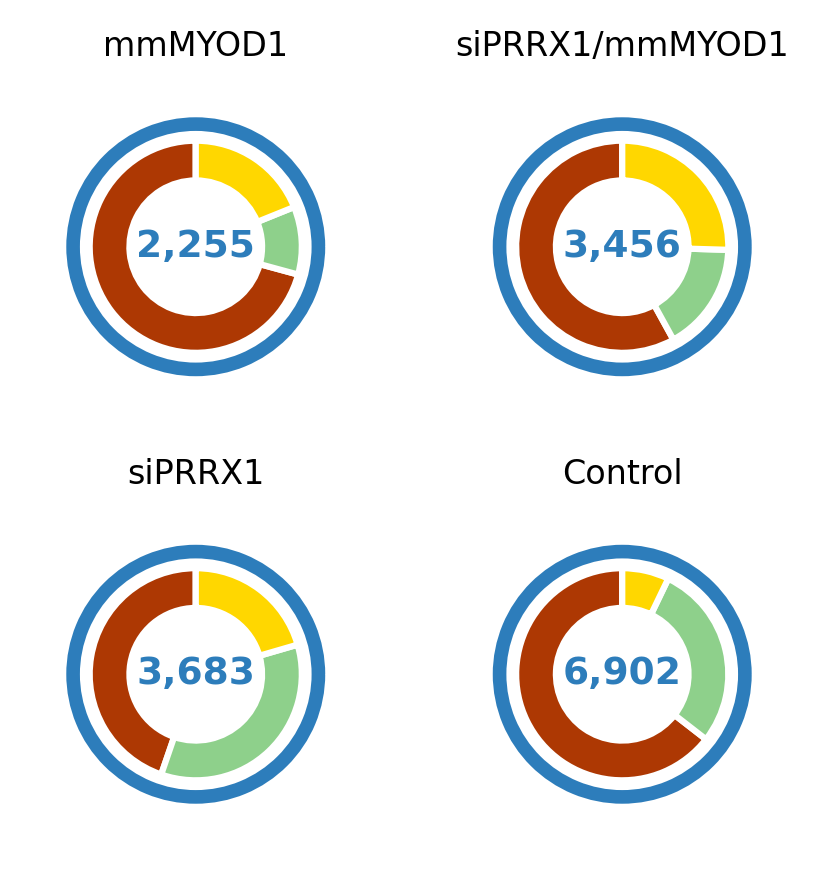

In [14]:
counts = adata.obs.groupby(['pooled_condition', 'phase'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase', values='count').fillna(0)

pivot_counts.head()


color_map = {
    "G1": '#ad3803',
    "S": 'gold',
    "G2M": '#8ed08b',#'#56b567',
}

# clusters = pivot_counts.index.tolist()
clusters = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control']

plt.rcParams['figure.figsize'] = 3, 3#6, 2
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

# Donut plots
for i, cluster in enumerate(clusters):
    ax = axes[i]
    data = pivot_counts.loc[cluster]
    colors = [color_map[cond] for cond in data.index]

    ax.pie(
        [1],   # single slice = all cells
        radius=1.0,
        colors=['#2D7DBB'],  # blue
        startangle=90,
        wedgeprops=dict(width=0.15, edgecolor='white', linewidth=1.5)
    )
    
    ax.pie(
        data,
        labels=None,
        startangle=90,
        colors=colors,
        wedgeprops=dict(linewidth=1.5, edgecolor='white', width=0.3, radius=0.8)
    )
    
    total_cells = int(data.sum())
    
    ax.text(
        0, 0,  # center of the pie
        f"{total_cells:,}",
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#2D7DBB',
    )
    
    # wedges, label = ax.pie(
    #     data,
    #     labels=None,
    #     startangle=90,
    #     colors=colors,
    #     wedgeprops=dict(linewidth=1, edgecolor='white', width=0.35),
    # )
    
    ax.set(aspect='equal')
    ax.set_title(f"{cluster}", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

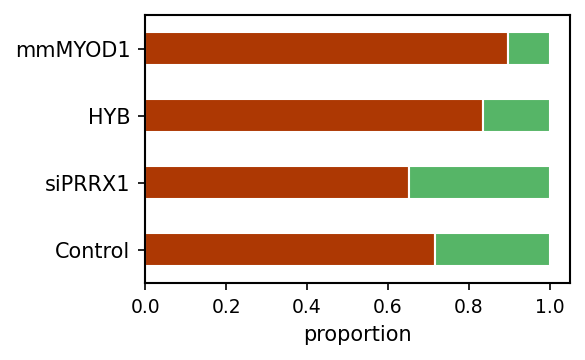

In [15]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2.5

counts = adata.obs.groupby(['pooled_condition', 'phase_grouped'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase_grouped', values='count').fillna(0)

col_order = ['G1S', 'G2M']
row_order = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']

pivot_counts = pivot_counts[col_order]
pivot_counts = pivot_counts.reindex(row_order)

df_prop = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)
# colors = ['#ad3803', 'gold', '#56b567']

color_map = {
    "G1S": '#ad3803',
    "G2M": '#56b567',#'#56b567',
}

# colors = ['#ad3803', 'gold', '#56b567']

df_prop.plot(
    kind='barh',
    stacked=True,
    color=color_map,
    legend=False,
    ec='white',
    width=0.5,
)

# tick_labels = ['+MYOD1', r'PRRX1$^{\mathrm{KD}}$+MYOD1', r'PRRX1$^{\mathrm{KD}}$', 'Control']
# tick_labels = ['Control', r'PRRX1$^{\mathrm{KD}}$', r'PRRX1$^{\mathrm{KD}}$+MYOD1', '+MYOD1']
tick_labels = ['Control', 'siPRRX1', 'HYB', 'mmMYOD1']
plt.ylabel("")
plt.yticks(ticks=range(len(row_order)), labels=tick_labels)

plt.xlabel("proportion")
plt.xticks(fontsize=9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.01) 
    
plt.tight_layout()
plt.show()

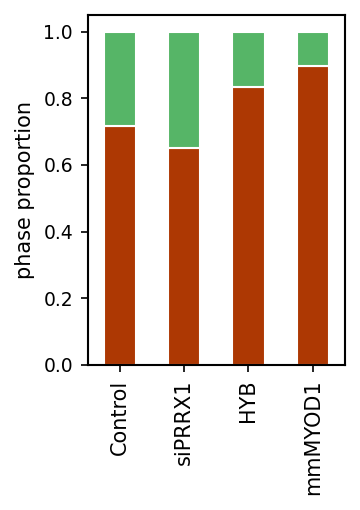

In [16]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 2.5, 3.5

counts = adata.obs.groupby(['pooled_condition', 'phase_grouped'], observed=True).size().reset_index(name='count')
pivot_counts = counts.pivot(index='pooled_condition', columns='phase_grouped', values='count').fillna(0)

col_order = ['G1S', 'G2M']
row_order = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']

pivot_counts = pivot_counts[col_order]
pivot_counts = pivot_counts.reindex(row_order)

df_prop = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)

color_map = {
    "G1S": '#ad3803',
    "G2M": '#56b567',#'#56b567',
}


df_prop.plot(
    kind='bar',
    stacked=True,
    color=color_map,
    legend=False,
    ec='white',
    width=0.5,
)

tick_labels = ['Control', 'siPRRX1', 'HYB', 'mmMYOD1']
plt.xlabel("")
plt.xticks(ticks=range(len(row_order)), labels=tick_labels)

plt.ylabel("phase proportion")
plt.yticks(fontsize=9)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.01) 
    
plt.tight_layout()
plt.show()

# Gene expression (subsets)

In [ ]:
# genes_of_interest = {
#     "DREAM": ['RBL1', 'RBL2', 'E2F4', 'E2F5', 'SIN3B', 'DYRK1A', 'PPP2CA', 'RBBP4'],
#     "MMB:FOXM1": ['MYBL2', 'FOXM1', 'YAP1', 'PCLAF'],
#     "RB:E2F": ['RB1', 'E2F1', 'E2F2', 'E2F3', 'PPP1CA', 'PPP2CA'],
#     "ACD": ['NUMB', 'NUMBL', 'HES1', 'PARD3', 'PARD6A', 'PRKCI', 'CDC42'],
#     "Notch": ['HES1', 'HEY1', 'NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4'],
#     "Hippo": ['SAV1', 'MOB1A', 'MOB1B', 'MST1', 'MST2', 'LATS1', 'LATS2', 'YAP1', 'WWTR1', 'TEAD1', 'TEAD2', 'TEAD3', 'TEAD4'],
#     "MyoD_cofactors": ['MEF2A', 'MEF2B', 'MEF2C', 'MEF2D', 'SIX1', 'SIX4', 'PBX1', 'PBX2', 'PBX3', 'SP1'],
#     "MyoD_inhibitors": ['ID1', 'ID2', 'ID3', 'ID4', 'MSC', 'MYOR', 'TWIST1', 'TWIST2', 'MIST1', 'BHLHA15', 'SNAI1', 'SNAI2', 'ZEB1'],
# }


# for pathway, genes in genes_of_interest.items():
    
#     genes_to_plot = [gene for gene in genes if gene in adata.var_names]
    
#     sc.pl.dotplot(
#         adata,
#         groupby='pooled_condition',
#         var_names=genes_to_plot,
#         layer='log_norm',
#         title=pathway,
#         standard_scale='var',
#     )
    
#     # break

In [ ]:
# genes_of_interest = {
#     "TGFB/SMAD signaling": ['TGFB1', 'TGFB2', 'TGFB3', 'SMAD2', 'SMAD3', 'SMAD4', 'TGFBR2', 'TGFBR1', 'ALK5', 'TGFBR3', 'ENG', 'SMAD7', 'SMURF1', 'SMURF2', 'PPM1A'],
#     "SMAD co-factors": ['EP300', 'CREBBP', 'FOXH1', 'RUNX1', 'RUNX2', 'YAP1', 'WWTR1', 'SP1'],
#     "TGFB non-canonical": ['TAK1', 'MAPK14', 'MAPK8', 'MAPK9', 'MAPK10', 'MAPK1', 'MAPK3', 'PIK3CA', 'PIK3R1', 'AKT1', 'AKT2', 'AKT3', 'MTOR',
#                            'RHOA', 'RAC1', 'CDC42', 'CHUK', 'IKBKB', 'NFKB1',],
#     "Others related to TGFB": ['SNAI2', 'ZEB1', 'ZEB2', 'TWIST1', 'JUN', 'FOS', 'ATF3', 'TP53', 'CDKN1A', 'MYC', 'SERPINE1', 'CTGF', 'CCN2', 'FN1', 
#                                'COL1A1', 'COL3A1', 'MMP2', 'MMP9', 'CDH1', 'VIM'],
# }


# for pathway, genes in genes_of_interest.items():
    
#     genes_to_plot = [gene for gene in genes if gene in adata.var_names]
    
#     sc.pl.dotplot(
#         adata,
#         groupby='pooled_condition',
#         var_names=genes_to_plot,
#         layer='log_norm',
#         title=pathway,
#         standard_scale='var',
#     )

# Pseudobulk

### By condition

In [17]:
adata.X = adata.layers['raw_counts'].copy()

cdata = sc.get.aggregate(
    adata, 
    by='pooled_condition',
    func='sum',
    axis=0,
)

cdata.X = cdata.layers['sum'].copy()

sc.pp.normalize_total(cdata, target_sum=1e4)
sc.pp.log1p(cdata)

cdata.layers['log_norm'] = cdata.X.copy()

cdata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 4 × 25126
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'log_norm'

In [18]:
ccdata = cdata[:, cc_genes].copy()

cond_order = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control']
ccdata = ccdata[cond_order, :].copy()

ccdata

AnnData object with n_obs × n_vars = 4 × 374
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'log_norm'

### By condition by phase

In [19]:
adata.X = adata.layers['raw_counts'].copy()

gdata = sc.get.aggregate(
    adata, 
    by='condition_by_phase_group',
    func='sum',
    axis=0,
)

gdata.X = gdata.layers['sum'].copy()

sc.pp.normalize_total(gdata, target_sum=1e4)
sc.pp.log1p(gdata)

gdata.layers['log_norm'] = gdata.X.copy()

gdata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 8 × 25126
    obs: 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'log_norm'

## Subset for G1/S and G2/M

In [20]:
# Select pseudobulk profiles by phase
G1S_cells = gdata.obs.query("condition_by_phase_group.str.contains('G1S')").index
G2M_cells = gdata.obs.query("condition_by_phase_group.str.contains('G2M')").index



# get genes unique to G1/S and G2/M
g1s_unique = list(set(G1S_genes) - set(G2M_genes))
g2m_unique = list(set(G2M_genes) - set(G1S_genes))

print(f"Unique to G1/S: {len(g1s_unique)}")
print(f"Unique to G2/M: {len(g2m_unique)}")


# # Make list of G1/S genes from cc_dict
# G1S_genes = []
# for phase in ["G1", "G1/S_transition", "S"]:
#     G1S_genes.extend(cc_dict[phase])
# G1S_genes = [str(g) for g in G1S_genes]
# G1S_genes_unique = list(dict.fromkeys(G1S_genes))
# G1S_genes_filtered = [g for g in G1S_genes_unique if g in gdata.var_names]
# print(f"N G1/S genes: {len(G1S_genes_filtered)}")
    
    
# # Make list of G2/M genes from cc_dict 
# G2M_genes = []
# for phase in ["G2/M_transition", "G2M"]:
#     G2M_genes.extend(cc_dict[phase])
# G2M_genes = [str(g) for g in G2M_genes]
# G2M_genes_unique = list(dict.fromkeys(G2M_genes))
# G2M_genes_filtered = [g for g in G2M_genes_unique if g in gdata.var_names]
# print(f"N G2M genes: {len(G2M_genes_filtered)}")   

Unique to G1/S: 74
Unique to G2/M: 75


In [21]:
# Make subsets of pseudobulk data
# g1s_gdata = gdata[G1S_cells, G1S_genes_filtered].copy()

unique_to_phase = False

if unique_to_phase:
    g1s_gdata = gdata[G1S_cells, g1s_unique].copy()
else:
    g1s_gdata = gdata[G1S_cells, G1S_genes].copy()
    
g1s_cond_order = ['mmMYOD1_G1S', 'siPRRX1/mmMYOD1_G1S', 'siPRRX1_G1S', 'Control_G1S']
g1s_gdata = g1s_gdata[g1s_cond_order, :].copy()


# g2m_gdata = gdata[G2M_cells, G2M_genes_filtered].copy()

if unique_to_phase:
    g2m_gdata = gdata[G2M_cells, g2m_unique].copy()
else:
    g2m_gdata = gdata[G2M_cells, G2M_genes].copy()
    
g2m_cond_order = ['mmMYOD1_G2M', 'siPRRX1/mmMYOD1_G2M', 'siPRRX1_G2M', 'Control_G2M']
g2m_gdata = g2m_gdata[g2m_cond_order, :].copy()


print(g1s_gdata.shape)
print(g2m_gdata.shape)

(4, 299)
(4, 300)


In [22]:
g2m_gdata.obs.head()

,condition_by_phase_group
mmMYOD1_G2M,mmMYOD1_G2M
siPRRX1/mmMYOD1_G2M,siPRRX1/mmMYOD1_G2M
siPRRX1_G2M,siPRRX1_G2M
Control_G2M,Control_G2M


## Correlation

Using log-norm expression...
(299, 4)


,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S,siPRRX1_G1S,Control_G1S
mmMYOD1_G1S,0.000000e+00,2.488349e-216,7.848370e-128,4.859031e-109
siPRRX1/mmMYOD1_G1S,2.488349e-216,0.000000e+00,2.408923e-183,1.951992e-132
siPRRX1_G1S,7.848370e-128,2.408923e-183,0.000000e+00,3.393230e-148
Control_G1S,4.859031e-109,1.951992e-132,3.393230e-148,0.000000e+00


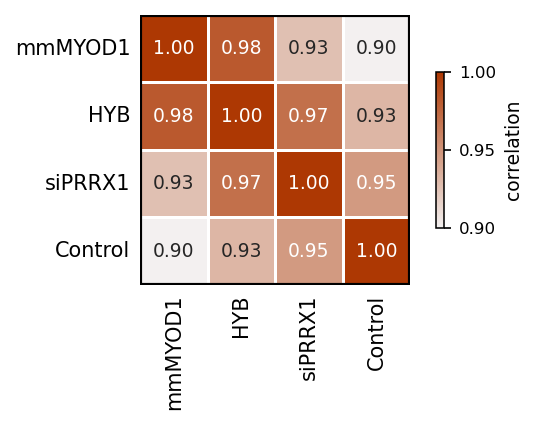

Using log-norm expression...
(300, 4)


,mmMYOD1_G2M,siPRRX1/mmMYOD1_G2M,siPRRX1_G2M,Control_G2M
mmMYOD1_G2M,0.000000e+00,4.495505e-258,1.146893e-183,8.346584e-159
siPRRX1/mmMYOD1_G2M,4.495505e-258,0.000000e+00,1.090350e-241,1.247504e-187
siPRRX1_G2M,1.146893e-183,1.090350e-241,0.000000e+00,3.271525e-202
Control_G2M,8.346584e-159,1.247504e-187,3.271525e-202,0.000000e+00


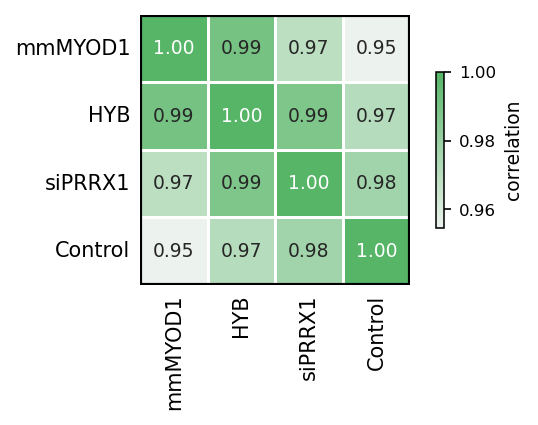

Using log-norm expression...
(374, 4)


,mmMYOD1,siPRRX1/mmMYOD1,siPRRX1,Control
mmMYOD1,0.000000e+00,2.235701e-253,5.233011e-145,3.738456e-128
siPRRX1/mmMYOD1,2.235701e-253,0.000000e+00,5.813401e-226,1.631366e-174
siPRRX1,5.233011e-145,5.813401e-226,0.000000e+00,3.721252e-207
Control,3.738456e-128,1.631366e-174,3.721252e-207,0.000000e+00


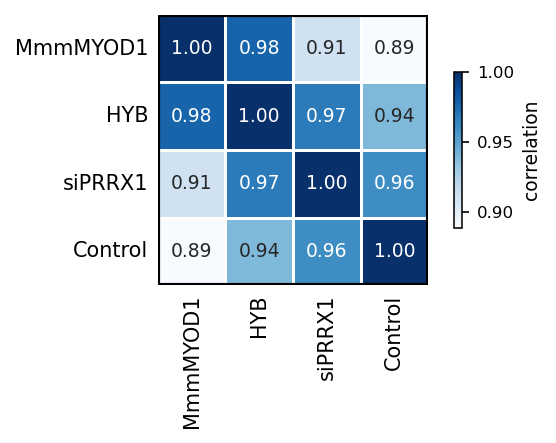

In [23]:
def correlation_heatmap(adata, dpi=200, figsize=(4, 4), cmap='magma', title='', label_map=None, zscore=False, cbar_label='correlation', corr='pearson'):

    if zscore:
        print("Computing Z score...")
        # compute gene-wise Z score
        expr = adata.to_df().T
        A = expr.apply(scipy.stats.zscore, axis=1, result_type='expand')
        A.columns = expr.columns
        print(A.shape)
    else:
        print("Using log-norm expression...")
        A = adata.to_df().T
        print(A.shape)
    
    conditions = A.columns
    n = len(conditions)

    corrs = np.zeros((n, n))
    ps = np.zeros((n, n))

    if corr == 'pearson':
        for i, cond1 in enumerate(conditions):
            for j, cond2 in enumerate(conditions):
                    # Compute Pearson correlation across all genes
                    corr, pval = pearsonr(A[cond1], A[cond2])
                    corrs[i, j] = corr
                    ps[i, j] = pval
    else:
        for i, cond1 in enumerate(conditions):
            for j, cond2 in enumerate(conditions):
                    # Compute spearman correlation across all genes
                    corr, pval = spearmanr(A[cond1], A[cond2])
                    corrs[i, j] = corr
                    ps[i, j] = pval

                    
    corr_df = pd.DataFrame(corrs, index=conditions, columns=conditions)
    pval_df = pd.DataFrame(ps, index=conditions, columns=conditions)

    display(pval_df)

    plt.rcParams['figure.dpi'] = dpi
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr_df,
        cmap=cmap,
        square=True,
        annot=True,
        annot_kws={'fontsize':9},
        fmt=".2f",
        lw=0.5,
        linecolor='white',
        cbar_kws={'label':cbar_label, 'shrink': 0.45, 'pad': 0.075, 'format': '%.2f'},
    )
    
    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    
    ax = plt.gca()
    
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.75)
    cbar.set_label(cbar_label, fontsize=9)
    
    xticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    yticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=10)
    ax.set_yticklabels(yticklabels, rotation=0, fontsize=10)
    ax.tick_params(axis='both', pad=1, bottom=False, left=False)
        
    n_rows, n_cols = corr_df.shape
    rect = patches.Rectangle(
        (0, 0), n_cols, n_rows,
        linewidth=2, edgecolor='black', facecolor='none', zorder=10
    )
    ax.add_patch(rect)
    
    plt.show()
    
    return corr_df
    

g1s_label_map = {
    'Control_G1S': 'Control',
    'mmMYOD1_G1S': 'mmMYOD1',
    'siPRRX1/mmMYOD1_G1S': 'HYB',
    'siPRRX1_G1S': 'siPRRX1',
}

g2m_label_map = {
    'Control_G2M': 'Control',
    'mmMYOD1_G2M': 'mmMYOD1',
    'siPRRX1/mmMYOD1_G2M': 'HYB',
    'siPRRX1_G2M': 'siPRRX1',
}

condition_label_map = {
    'Control': 'Control',
    'mmMYOD1': 'MmmMYOD1',
    'siPRRX1/mmMYOD1': 'HYB',
    'siPRRX1': 'siPRRX1',
}

g1s_cmap = sns.light_palette("#ad3803", as_cmap=True)
g2m_cmap = sns.light_palette("#56b567", as_cmap=True)

# title=f'Unique to G1/S (n={len(g1s_unique)})'
# title=f'Unique to G2/M (n={len(g2m_unique)})'
# title=f'Cell cycle genes (n={len(cc_genes)})'

dpi = 150
corr_method = 'pearson'

corr_df = correlation_heatmap(g1s_gdata, title='', cmap=g1s_cmap, label_map=g1s_label_map, dpi=dpi, figsize=(3, 3), corr=corr_method)
corr_df1 = correlation_heatmap(g2m_gdata, title='', cmap=g2m_cmap, label_map=g2m_label_map, dpi=dpi, figsize=(3, 3), corr=corr_method)
corr_df2 = correlation_heatmap(ccdata, title='', cmap='Blues', label_map=condition_label_map, dpi=dpi, figsize=(3, 3), corr=corr_method)

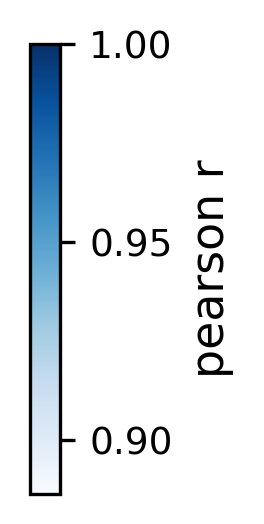

In [56]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(figsize=(1, 2.5))

# vmin = corr_df.min().min()
# vmax = corr_df.max().max()
# vmin = corr_df1.min().min()
# vmax = corr_df1.max().max()
vmin = corr_df2.min().min()
vmax = corr_df2.max().max()

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    cax=ax, orientation='vertical'
)

ax.set_position([0.2, 0.1, 0.1, 0.6]) # [left, bottom, width, height] in figure coordinates

cbar.set_label("pearson r", fontsize=11)
cbar.ax.tick_params(labelsize=9)

cbar.locator = MaxNLocator(nbins=3, prune=None, steps=[1, 2, 5, 10])
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.show()

## Expression (z-score)

In [36]:
def plot_condition_scatter(df, cond1, cond2, title=''):
    
    x = df[cond1].values
    y = df[cond2].values

    # Compute correlation
    r, p = pearsonr(x, y)

    # Fit line for plotting
    m, b = np.polyfit(x, y, 1)
    line = m * x + b

    # Make plot
    plt.rcParams['figure.dpi'] = 200
    fig, ax = plt.subplots(figsize=(3, 3))
    
    ax.grid(True, which="major", linewidth=0.5, linestyle="--", alpha=0.7, zorder=1)
    
    ax.scatter(
        x,
        y,
        s=10,
        linewidths=0,
        zorder=2,
    )
    
    ax.plot(x, line, color="red", lw=1, ls="-", zorder=3)
    
    xlabel = cond1.split("_")[0]
    ylabel = cond2.split("_")[0]
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Annotate r and p
    ax.text(0.65, 0.95, f"r = {r:.2f}\np = {p:.2e}",#f"r = {r:.2f}     p = {p:.2e}", 
             transform=ax.transAxes,
             verticalalignment="top", fontsize=8,
             bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
    ax.set_aspect('equal', adjustable='box')

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

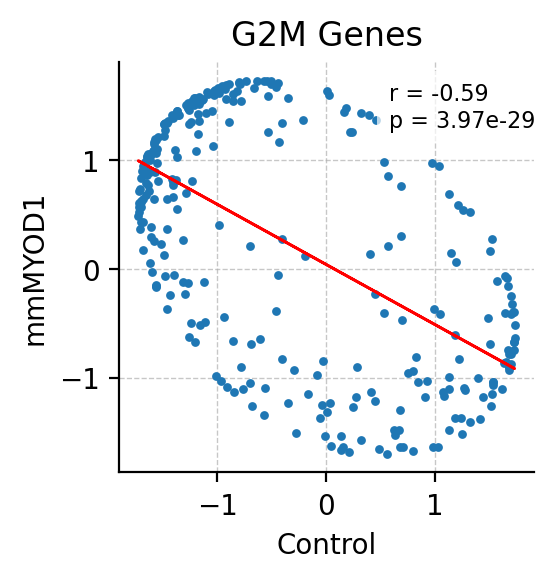

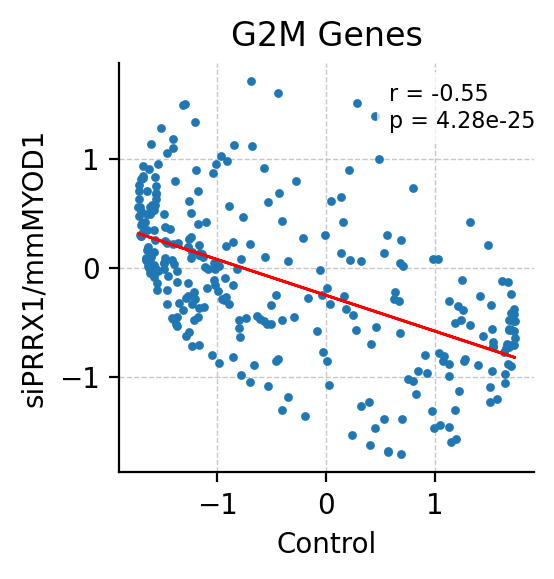

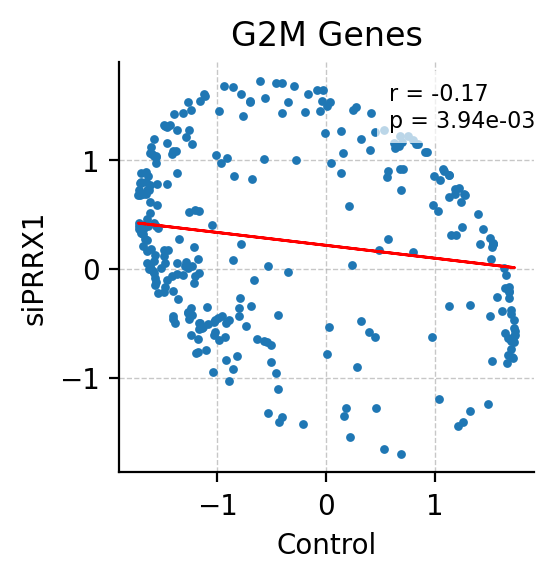

In [37]:
expr = g2m_gdata.to_df()
expr_z = expr.apply(scipy.stats.zscore, axis=0)
expr_z = expr_z.T

plot_condition_scatter(expr_z, 'Control_G2M', 'mmMYOD1_G2M', title='G2M Genes')
plot_condition_scatter(expr_z, 'Control_G2M', 'siPRRX1/mmMYOD1_G2M', title='G2M Genes')
plot_condition_scatter(expr_z, 'Control_G2M', 'siPRRX1_G2M', title='G2M Genes')

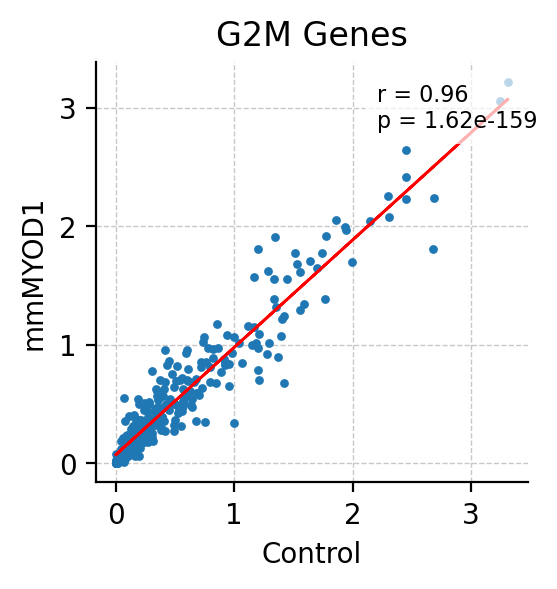

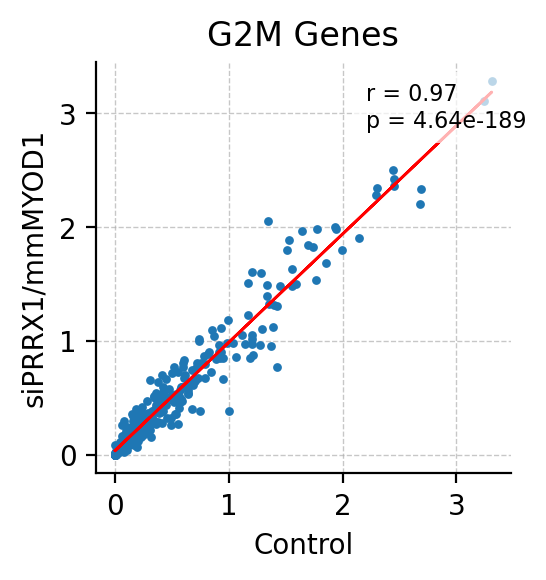

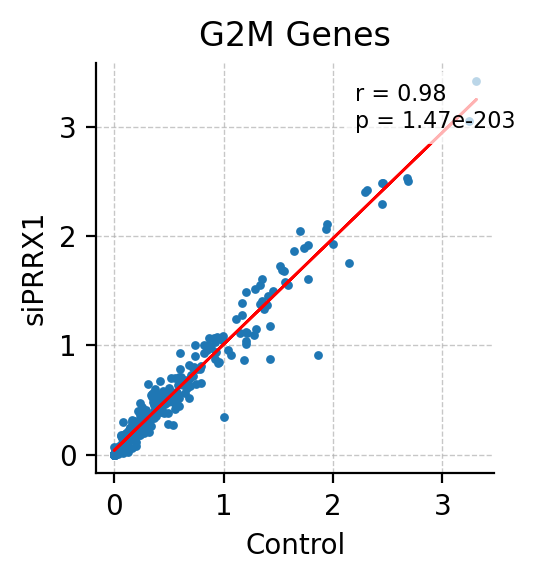

In [39]:
expr = g2m_gdata.to_df()
# expr_z = expr.apply(scipy.stats.zscore, axis=0)
expr = expr.T

plot_condition_scatter(expr, 'Control_G2M', 'mmMYOD1_G2M', title='G2M Genes')
plot_condition_scatter(expr, 'Control_G2M', 'siPRRX1/mmMYOD1_G2M', title='G2M Genes')
plot_condition_scatter(expr, 'Control_G2M', 'siPRRX1_G2M', title='G2M Genes')

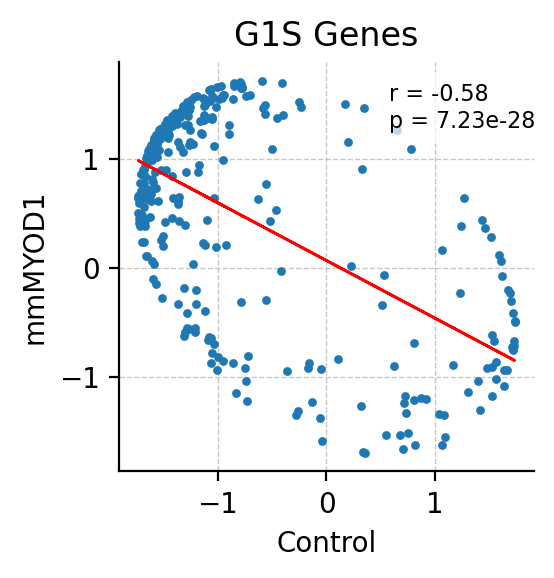

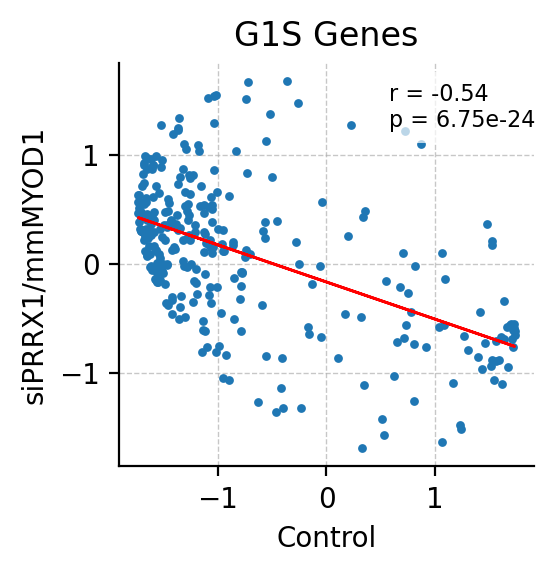

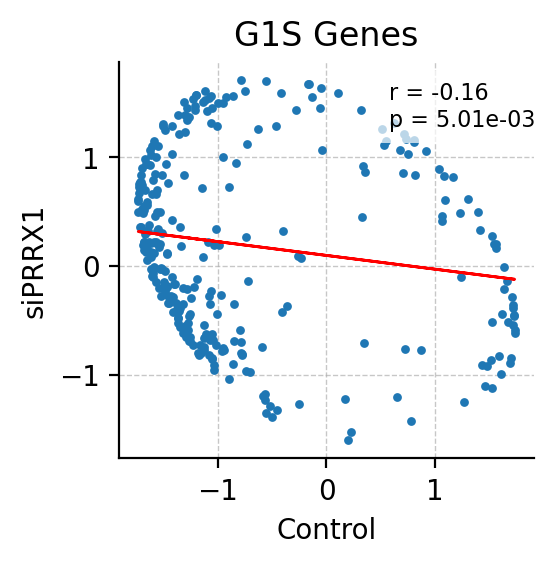

In [38]:
expr = g1s_gdata.to_df()
expr_z = expr.apply(scipy.stats.zscore, axis=0)
expr_z = expr_z.T

plot_condition_scatter(expr_z, 'Control_G1S', 'mmMYOD1_G1S', title='G1S Genes')
plot_condition_scatter(expr_z, 'Control_G1S', 'siPRRX1/mmMYOD1_G1S', title='G1S Genes')
plot_condition_scatter(expr_z, 'Control_G1S', 'siPRRX1_G1S', title='G1S Genes')

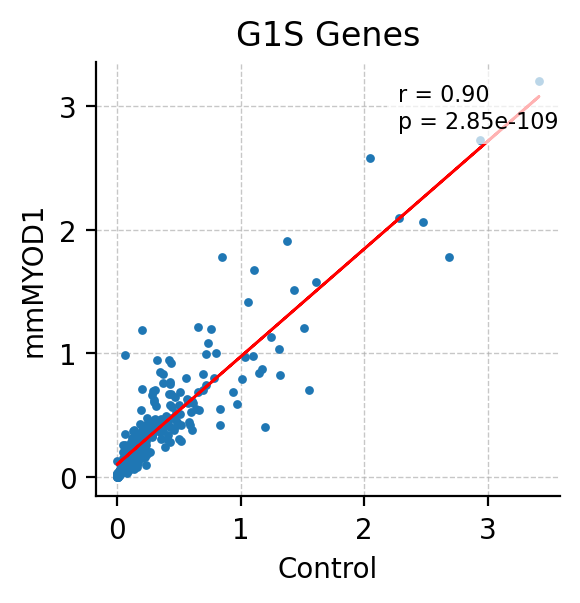

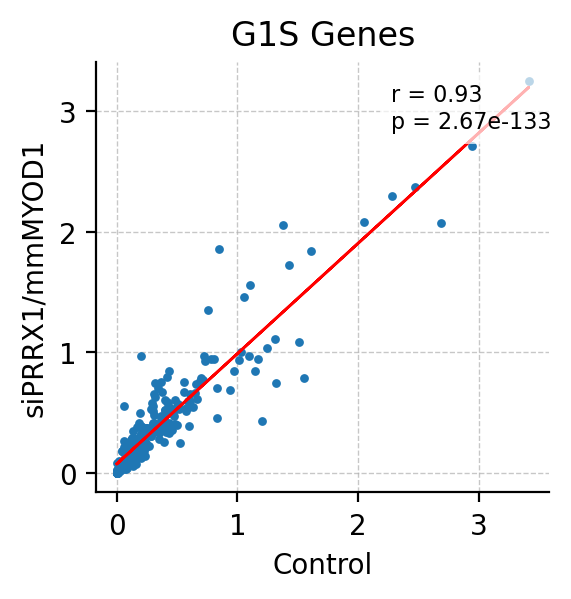

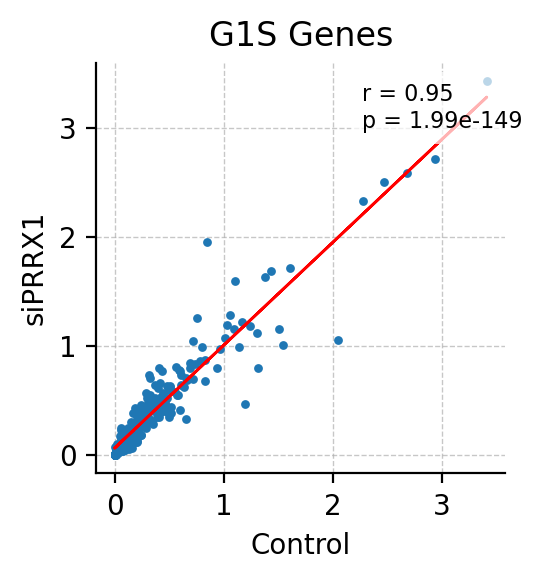

In [40]:
expr = g1s_gdata.to_df()
# expr_z = expr.apply(scipy.stats.zscore, axis=0)
expr = expr.T

plot_condition_scatter(expr, 'Control_G1S', 'mmMYOD1_G1S', title='G1S Genes')
plot_condition_scatter(expr, 'Control_G1S', 'siPRRX1/mmMYOD1_G1S', title='G1S Genes')
plot_condition_scatter(expr, 'Control_G1S', 'siPRRX1_G1S', title='G1S Genes')

In [110]:
query = 'G2/M'

cells_to_keep = adata.obs['condition_by_phase_group'].str.endswith(query)

adata_subset = adata[cells_to_keep, :].copy()

# compute z score for all genes
adata_subset.X = adata_subset.layers['log_norm'].copy()
expr = adata_subset.X

if hasattr(expr, "toarray"):
    expr = expr.toarray()

z_expr = scipy.stats.zscore(expr, axis=0, ddof=0)

adata_subset.layers["zscore"] = z_expr

adata_subset

AnnData object with n_obs × n_vars = 6096 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'condition_by_phase', 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_vari

In [112]:
tmp = adata_subset[:, G2M_genes_filtered].copy()
tmp

AnnData object with n_obs × n_vars = 6096 × 104
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'condition_by_phase', 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variab

In [136]:
hvgs = tmp.var[tmp.var['highly_variable'] == True]

hvgs = hvgs[['highly_variable', 'highly_variable_rank']]

hvgs = hvgs.sort_values(by='highly_variable_rank')

hvgs = hvgs.reset_index()

hvgs.head()

,gene_name,highly_variable,highly_variable_rank
0,TOP2A,True,41.0
1,HMGB2,True,53.0
2,CENPF,True,65.0
3,UBE2C,True,128.0
4,CKS1B,True,145.0


In [128]:
genes_to_plot = hvgs['gene_name'].head(10).tolist()
genes_to_plot

['TOP2A',
 'HMGB2',
 'CENPF',
 'UBE2C',
 'CKS1B',
 'MKI67',
 'CKS2',
 'NUSAP1',
 'TPX2',
 'CCNB1']

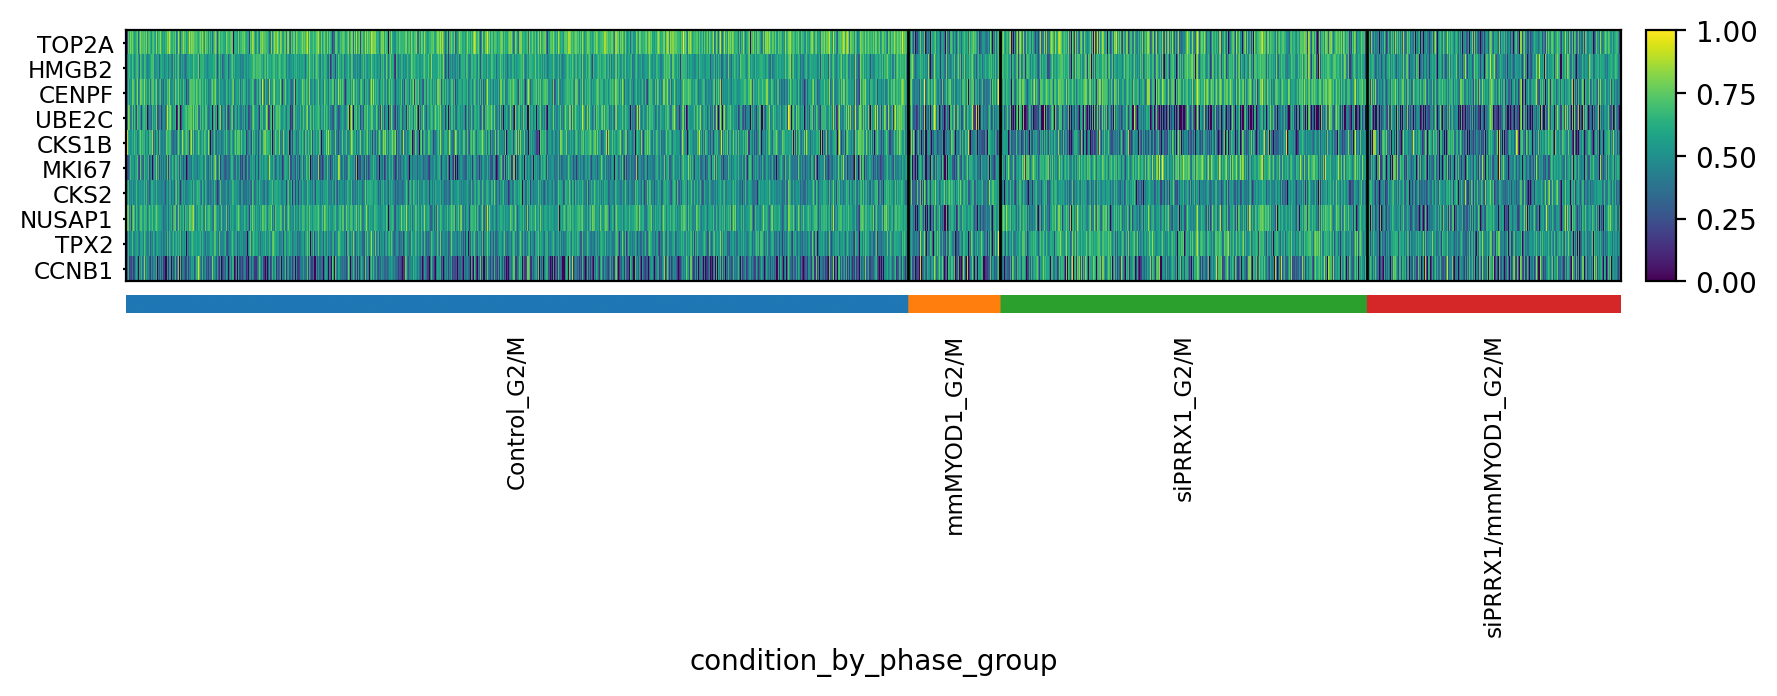

In [135]:
genes_to_plot = hvgs['gene_name'].head(10).tolist()

sc.pl.heatmap(
    adata_subset,
    var_names=genes_to_plot,
    groupby='condition_by_phase_group',
    layer='log_norm',
    standard_scale='var',
    swap_axes=True,
    # vmin=-1,
    # vmax=1,
)

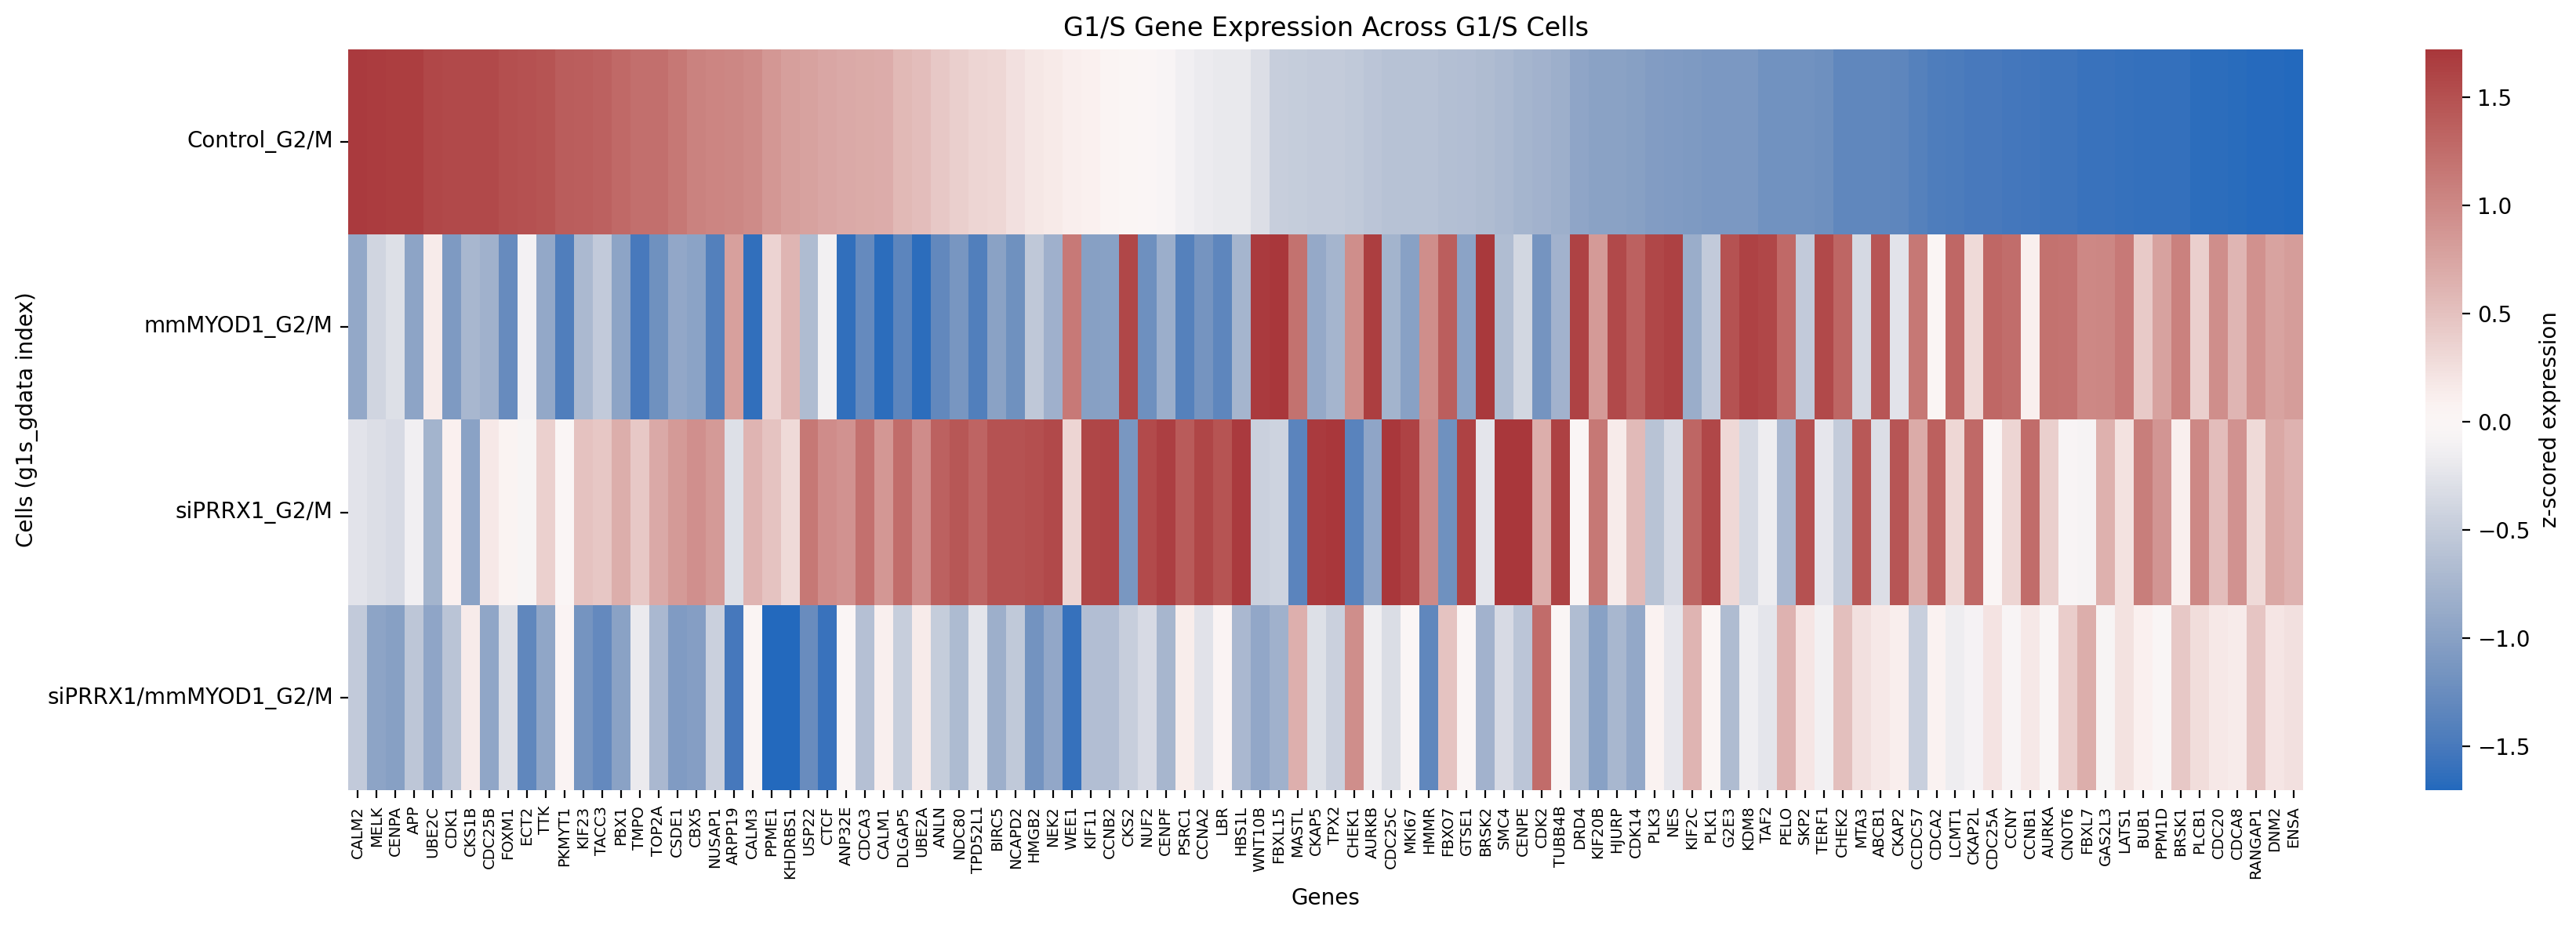

In [153]:
expr = g2m_gdata.to_df()

expr_z = expr.apply(scipy.stats.zscore, axis=0)

# ['Control_G1/S']
ordered_genes = expr_z.loc['Control_G2/M'].sort_values(ascending=False).index
expr_z_ordered = expr_z.loc[:, ordered_genes]

plt.figure(figsize=(18, 6))
sns.heatmap(
    expr_z_ordered,
    cmap="vlag",
    yticklabels=True,   # show cell index names
    xticklabels=True,   # show gene names
    cbar_kws={"label": "z-scored expression"}
)

plt.title("G1/S Gene Expression Across G1/S Cells")
plt.xlabel("Genes")
plt.ylabel("Cells (g1s_gdata index)")

plt.xticks(fontsize=7)

plt.tight_layout()
plt.show()

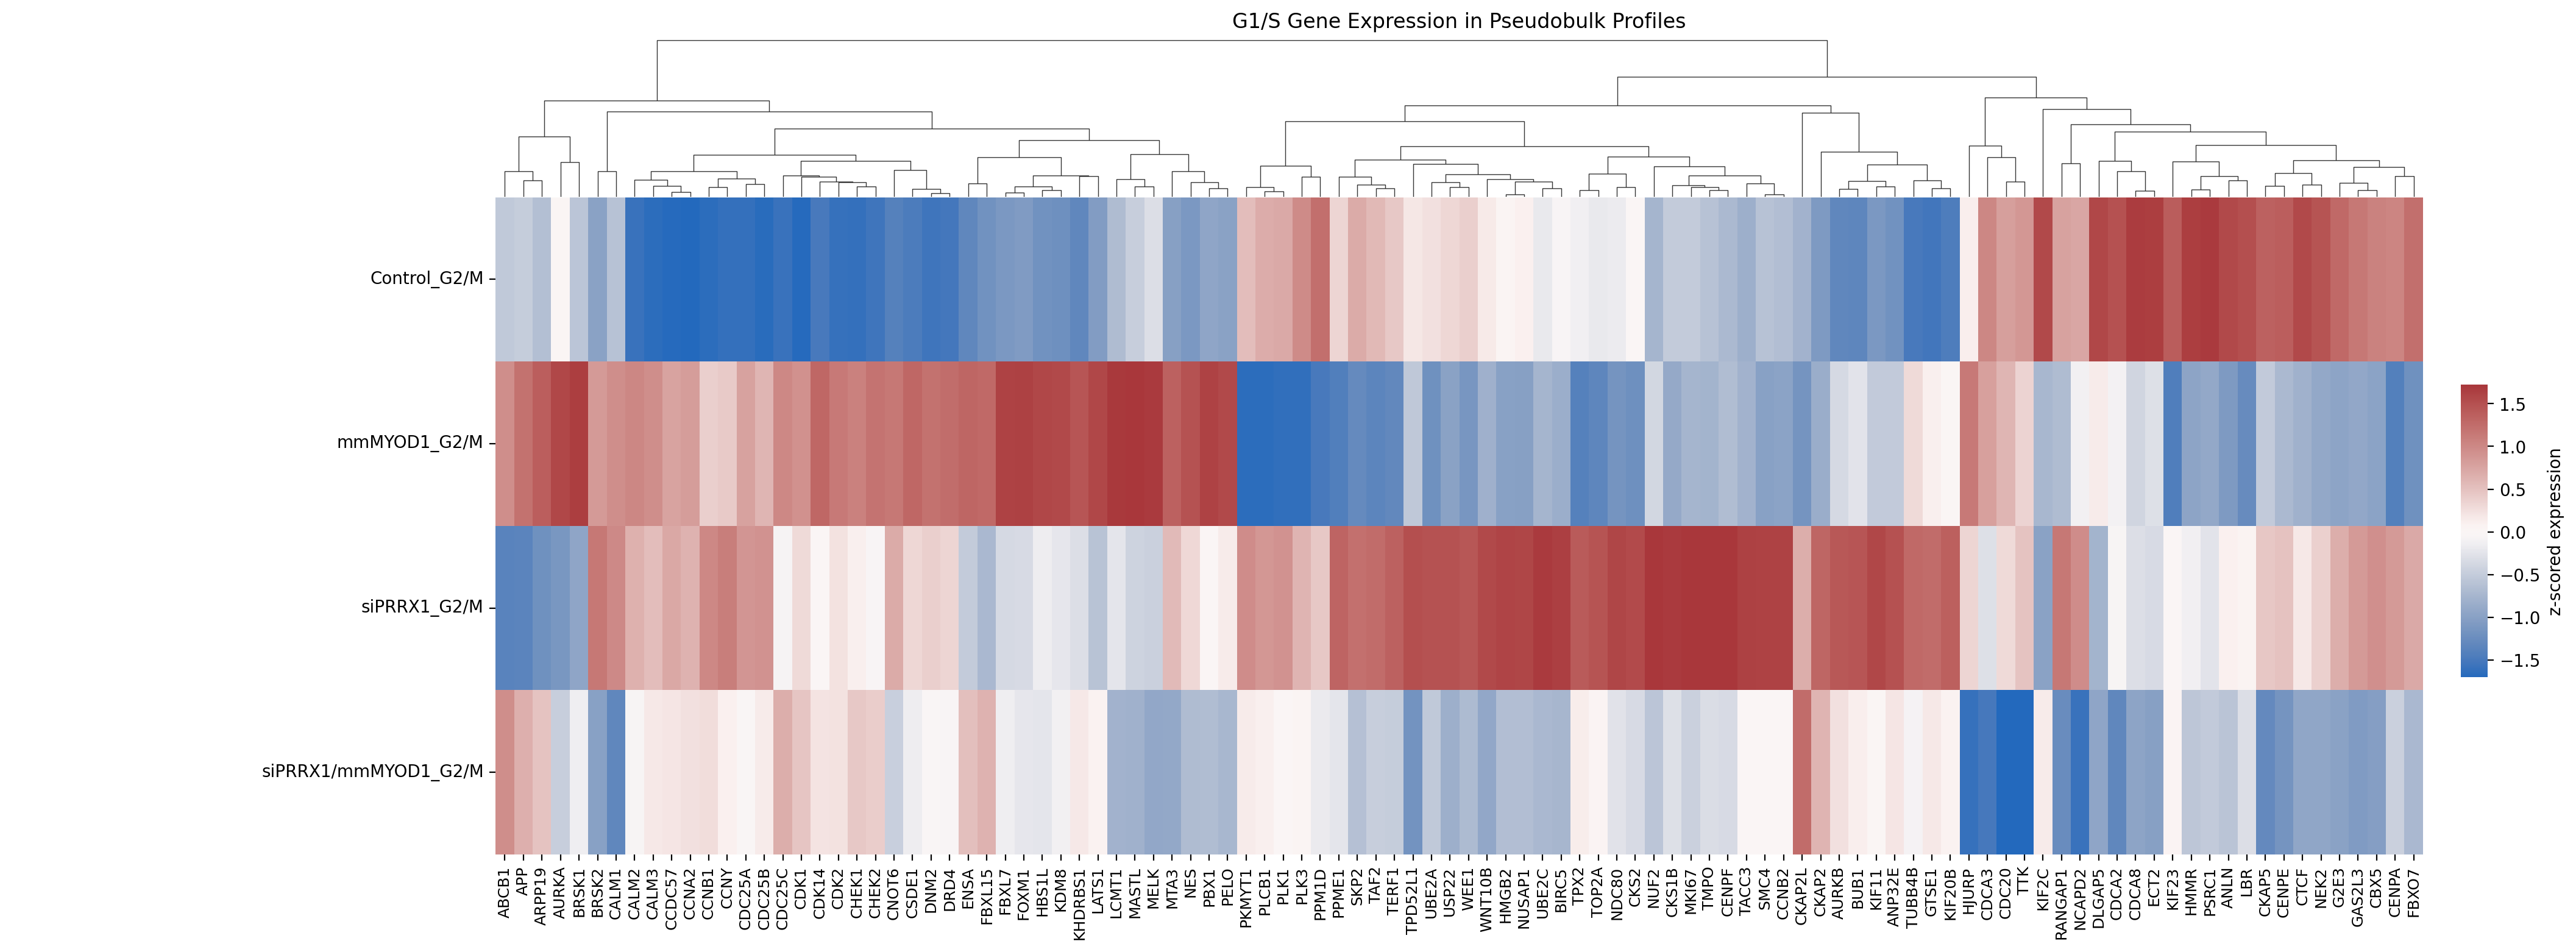

In [154]:
plt.rcParams['figure.dpi'] = 200
figsize=(22, 8)

g = sns.clustermap(
    expr_z,                 
    cmap="vlag",
    row_cluster=False,        
    figsize=figsize,
    cbar_kws={"label": "z-scored expression", 'shrink': 0.25, 'pad': 0.4}
)

g.ax_heatmap.set_title("G1/S Gene Expression in Pseudobulk Profiles", pad=100)
g.cax.set_position([.92, .32, .01, .3])  

g.ax_heatmap.yaxis.set_label_position("left")
g.ax_heatmap.yaxis.tick_left()

g.ax_heatmap.xaxis.set_label_text("")

n_genes = expr_z.shape[1]

g.ax_heatmap.set_xticks([x + 0.5 for x in range(n_genes)])
g.ax_heatmap.set_xticklabels(
    expr_z.columns,
    fontsize=9,   # adjust to taste
    rotation=90   # vertical so they don’t overlap
)

plt.show()

In [157]:
# extract specific groups of genes from plot
start_gene = 'ABCB1'
end_gene = 'PELO'

all_genes = expr_z.columns.tolist()

start_idx = all_genes.index(start_gene)
end_idx = all_genes.index(end_gene)

gene_range = all_genes[start_idx:end_idx+1] # inclusive
print(len(gene_range))



40


## enrichr

In [159]:
# pd.set_option('display.max_colwidth', None)

enr = gget.enrichr(
    gene_range,
    "GO_Biological_Process_2025",
    save=False,
)

display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(25))

16:18:49 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,G2/M Transition of Mitotic Cell Cycle (GO:0000086),"[BRSK1, KHDRBS1, BRSK2, KDM8, FOXM1, ARPP19, AURKA, CCNB1, CHEK2, ENSA, LCMT1, CCDC57, FBXL15, CDC25C, MASTL, CDC25A, CDC25B, DNM2, CCNA2, LATS1, MELK, CCNY, CDK2, CDK1, CDK14, NES, FBXL7]",6.727624e-66
1,Cell Cycle G2/M Phase Transition (GO:0044839),"[BRSK1, KHDRBS1, BRSK2, KDM8, FOXM1, ARPP19, AURKA, CCNB1, CHEK2, ENSA, LCMT1, CCDC57, FBXL15, CDC25C, MASTL, CDC25A, CDC25B, DNM2, CCNA2, LATS1, MELK, CCNY, CDK2, CDK1, CDK14, NES, FBXL7]",7.402421e-65
2,Mitotic Cell Cycle Phase Transition (GO:0044772),"[BRSK1, KHDRBS1, BRSK2, KDM8, FOXM1, ARPP19, AURKA, CCNB1, CHEK2, ENSA, LCMT1, CCDC57, FBXL15, CDC25C, MASTL, CDC25A, CDC25B, DNM2, CCNA2, LATS1, MELK, CCNY, CDK2, CDK1, CDK14, NES, FBXL7]",1.512676e-50
3,Positive Regulation of Cell Cycle (GO:0045787),"[APP, CCNB1, CCNY, CCDC57, CHEK1, AURKA, CDC25B]",3.771100e-09
4,G1/S Transition of Mitotic Cell Cycle (GO:0000082),"[CCNA2, LATS1, KHDRBS1, CCNB1, CDK2, CDK1, CDC25A]",4.824716e-09
5,Cell Cycle G1/S Phase Transition (GO:0044843),"[CCNA2, LATS1, KHDRBS1, CCNB1, CDK2, CDK1, CDC25A]",5.025891e-09
6,Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010389),"[CCNB1, CDK2, CDK1, CDC25C, CDC25A, CDC25B]",7.871731e-09
7,Regulation of Mitotic Cell Cycle (GO:0007346),"[APP, CCNB1, CCDC57, CDK2, CDC25C, MASTL, AURKA, CDC25B]",8.118224e-09
8,Positive Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010971),"[CCNB1, CDK1, CDC25C, CDC25A, CDC25B]",2.387731e-08
9,Positive Regulation of Cell Cycle G2/M Phase Transition (GO:1902751),"[CCNB1, CDK1, CDC25C, CDC25A, CDC25B]",4.643667e-08


In [133]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [138]:
[col for col in geneset if "circadian" in col.lower()]

['Entrainment of Circadian Clock by Photoperiod (GO:0043153)',
 'Negative Regulation of Circadian Rhythm (GO:0042754)',
 'Positive Regulation of Circadian Rhythm (GO:0042753)',
 'Regulation of Circadian Sleep/Wake Cycle (GO:0042749)',
 'Regulation of Circadian Sleep/Wake Cycle, Sleep (GO:0045187)']

# Correlation (within group)

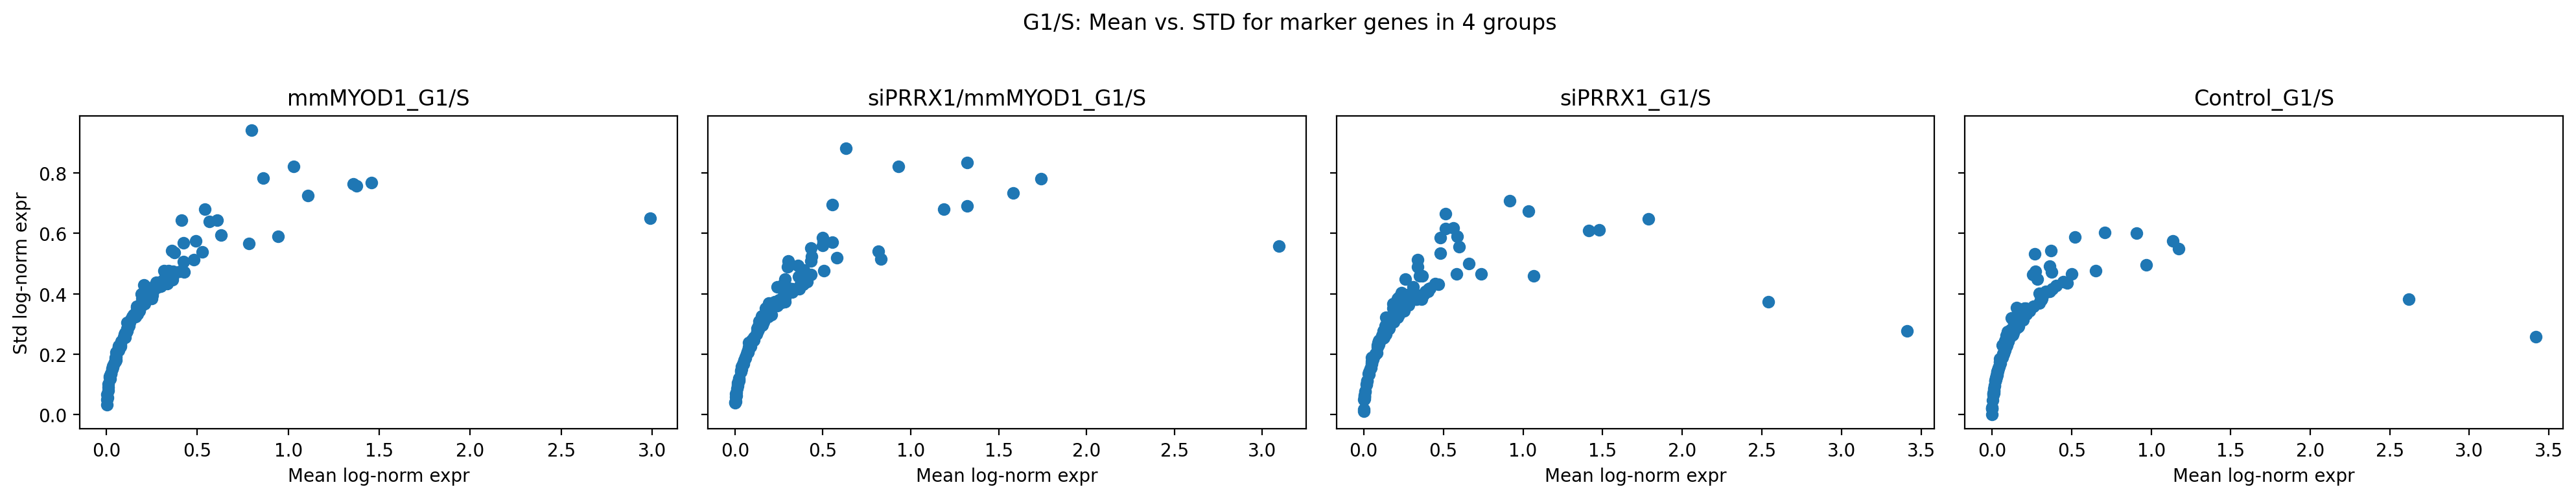

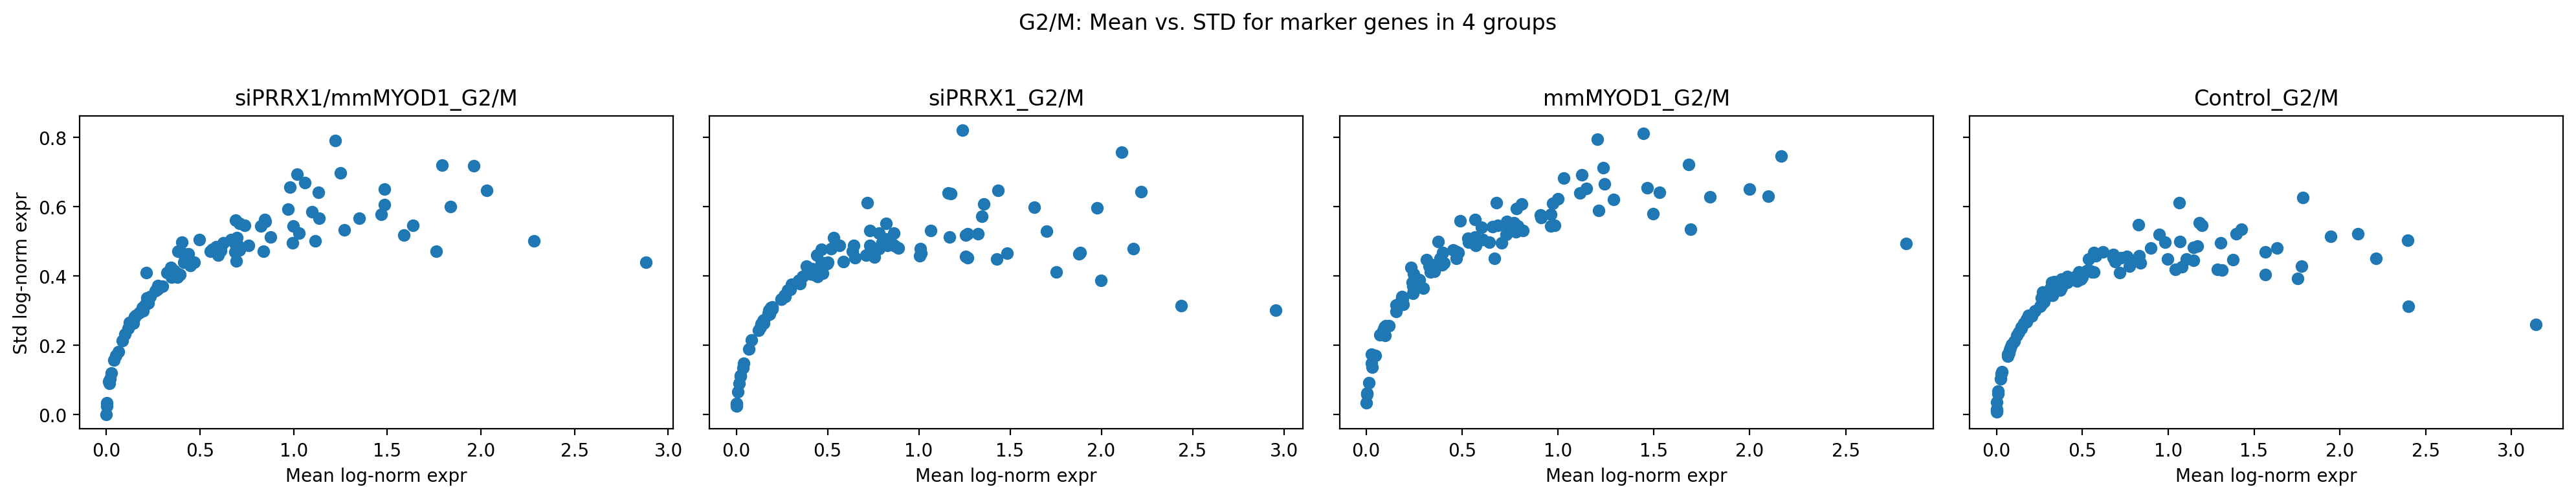

In [188]:
def plot_group_scatter_dense(groups, gene_list, phase_name):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    for i, group in enumerate(groups):
        ax = axes[i]
        idx = adata.obs['condition_by_phase_group'] == group
        group_data = adata[idx]
        genes_in_var = [g for g in gene_list if g in group_data.var_names]
        if not genes_in_var:
            print(f"No {phase_name} genes present in var_names for group {group}")
            continue
        gene_idx = group_data.var_names.get_indexer(genes_in_var)
        expr = group_data.layers['log_norm'][:, gene_idx]
        # Always convert to dense:
        try:
            expr_dense = expr.toarray()  # Works if sparse
        except AttributeError:
            expr_dense = np.asarray(expr)  # Works if already dense
        means = np.mean(expr_dense, axis=0)
        stds = np.std(expr_dense, axis=0)
        ax.scatter(means, stds)
        ax.set_title(group)
        ax.set_xlabel('Mean log-norm expr')
        if i == 0:
            ax.set_ylabel('Std log-norm expr')
    plt.suptitle(f'{phase_name}: Mean vs. STD for marker genes in 4 groups')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




g1s_groups = [g for g in adata.obs['condition_by_phase_group'].unique() if g.endswith('_G1/S')]
g2m_groups = [g for g in adata.obs['condition_by_phase_group'].unique() if g.endswith('_G2/M')]

plot_group_scatter_dense(g1s_groups, G1S_genes_filtered, 'G1/S')
plot_group_scatter_dense(g2m_groups, G2M_genes_filtered, 'G2/M')

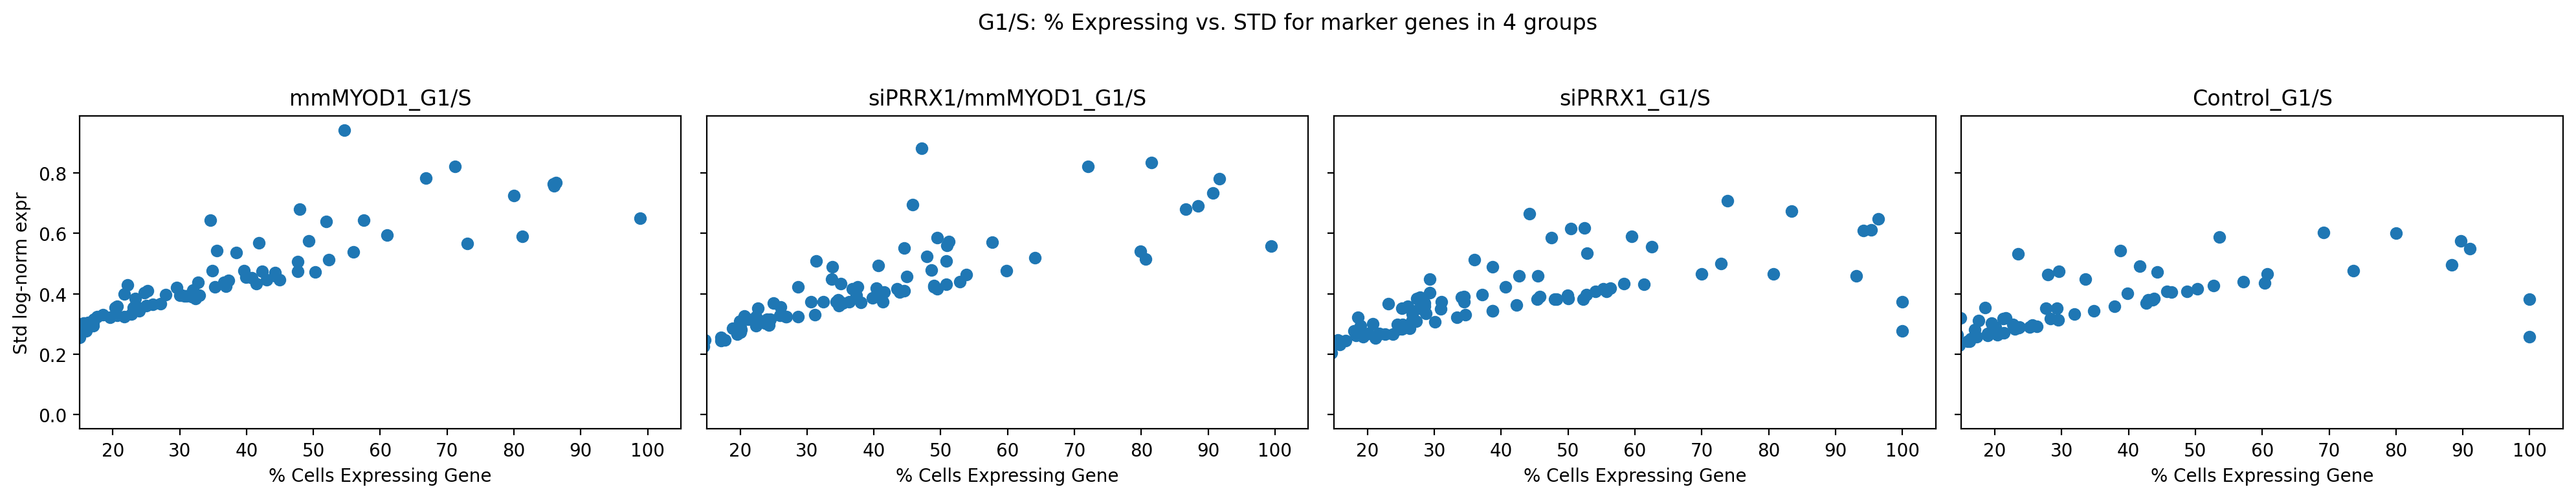

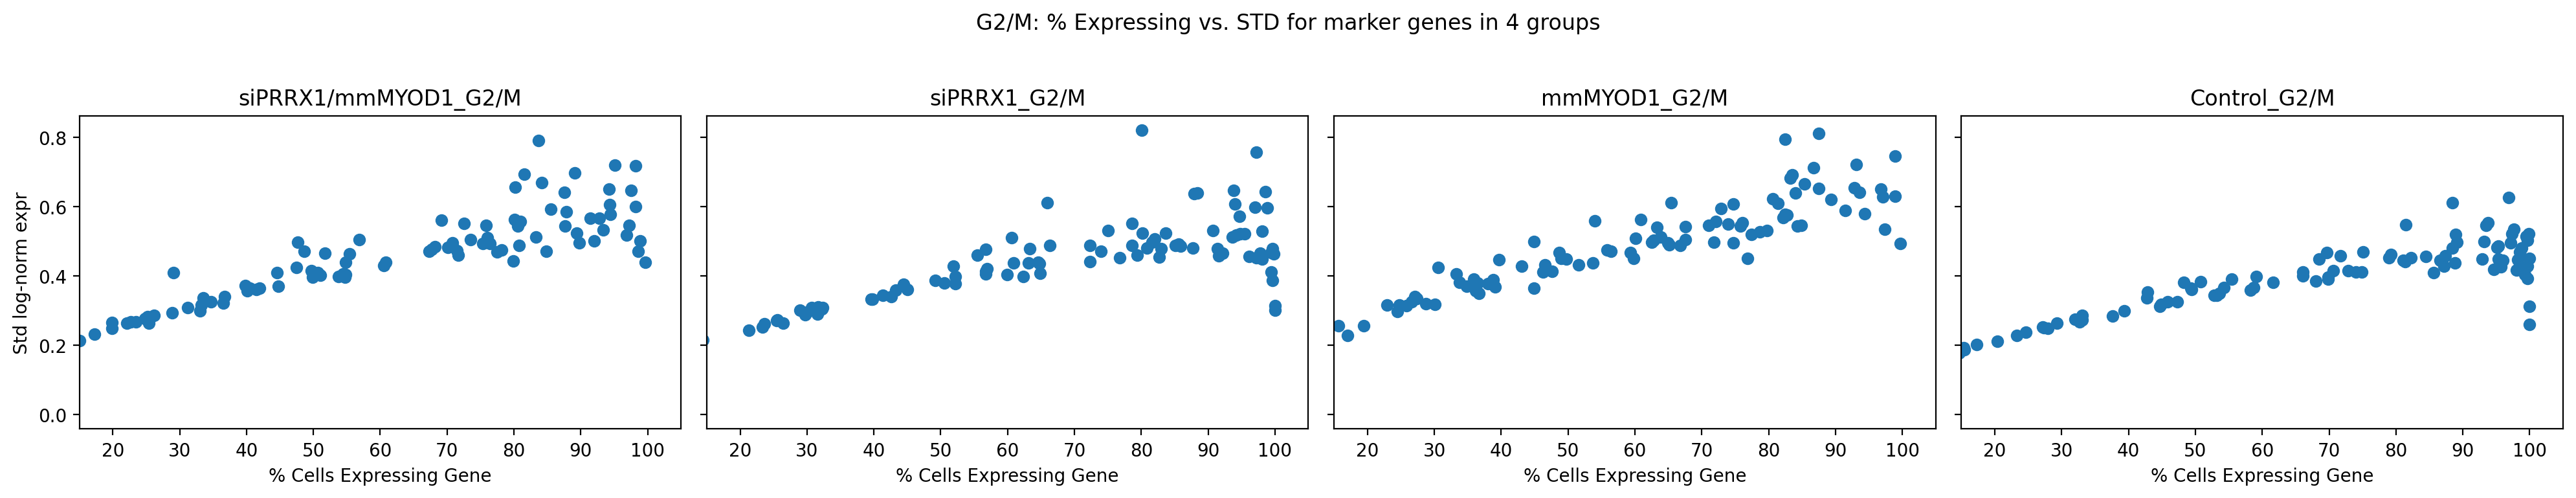

In [191]:
def plot_group_scatter_percent_nonzero(groups, gene_list, phase_name):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    for i, group in enumerate(groups):
        ax = axes[i]
        idx = adata.obs['condition_by_phase_group'] == group
        group_data = adata[idx]
        genes_in_var = [g for g in gene_list if g in group_data.var_names]
        if not genes_in_var:
            print(f"No {phase_name} genes present in var_names for group {group}")
            continue
        gene_idx = group_data.var_names.get_indexer(genes_in_var)
        expr = group_data.layers['log_norm'][:, gene_idx]
        try:
            expr_dense = expr.toarray()
        except AttributeError:
            expr_dense = np.asarray(expr)
        # Percent non-zero per gene
        percent_nonzero = (expr_dense > 0).sum(axis=0) / expr_dense.shape[0] * 100
        stds = np.std(expr_dense, axis=0)
        
        ax.scatter(percent_nonzero, stds)
        ax.set_title(group)
        ax.set_xlabel('% Cells Expressing Gene')
        if i == 0:
            ax.set_ylabel('Std log-norm expr')
        ax.set_xlim([15, 105])
    plt.suptitle(f'{phase_name}: % Expressing vs. STD for marker genes in 4 groups')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    
plot_group_scatter_percent_nonzero(g1s_groups, G1S_genes_filtered, 'G1/S')
plot_group_scatter_percent_nonzero(g2m_groups, G2M_genes_filtered, 'G2/M')

# Pseudotime

Do pseudotime ordering for each group separately, assess how expression of specific genes changes over pseudotime

In [137]:
def find_closest_cell(adata, obs_key='phase', value='G1', obsm_key='X_pca', dataset=None):
    """
    Find the cell closest to a median vector in PCA space for a given group and optional dataset.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group.
        value (str): The value for aggregation (e.g., 'G1').
        obsm_key (str): Key in adata.obsm for PCA or other embedding (e.g., 'X_pca').
        dataset (str, optional): Name of dataset in adata.obs['dataset'] to restrict search.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest matching cell in adata.obs_names.
    """
    mask = adata.obs[obs_key] == value
    if dataset is not None:
        mask &= adata.obs['dataset'] == dataset

    emb = adata.obsm[obsm_key][mask]
    
    if emb.shape[0] == 0:
        raise ValueError("No cells match the specified filters.")

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index
# find_closest_cell(adata, value='G1', obsm_key='X_pca_harmony', dataset='Control')

In [138]:
adata

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'condition_by_phase', 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_var

In [165]:
# conditions = adata.obs['pooled_condition'].unique()

# adata_split = {cond: adata[adata.obs['pooled_condition'] == cond].copy() for cond in conditions}

# # adata_split.keys()

# hyb_adata = adata_split[conditions[0]]
# myod_adata = adata_split[conditions[1]]
# prrx_adata = adata_split[conditions[2]]
# control_adata = adata_split[conditions[3]]

# hyb_adata

AnnData object with n_obs × n_vars = 3451 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'condition_by_phase', 'condition_by_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_vari


G1: cell_id='CCAGTATGTTTGGAAG_control' root_idx=np.int64(11569)

computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)

G2M: cell_id='TGCTACTTCGTGCTCC_control' root_idx=np.int64(15683)

computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


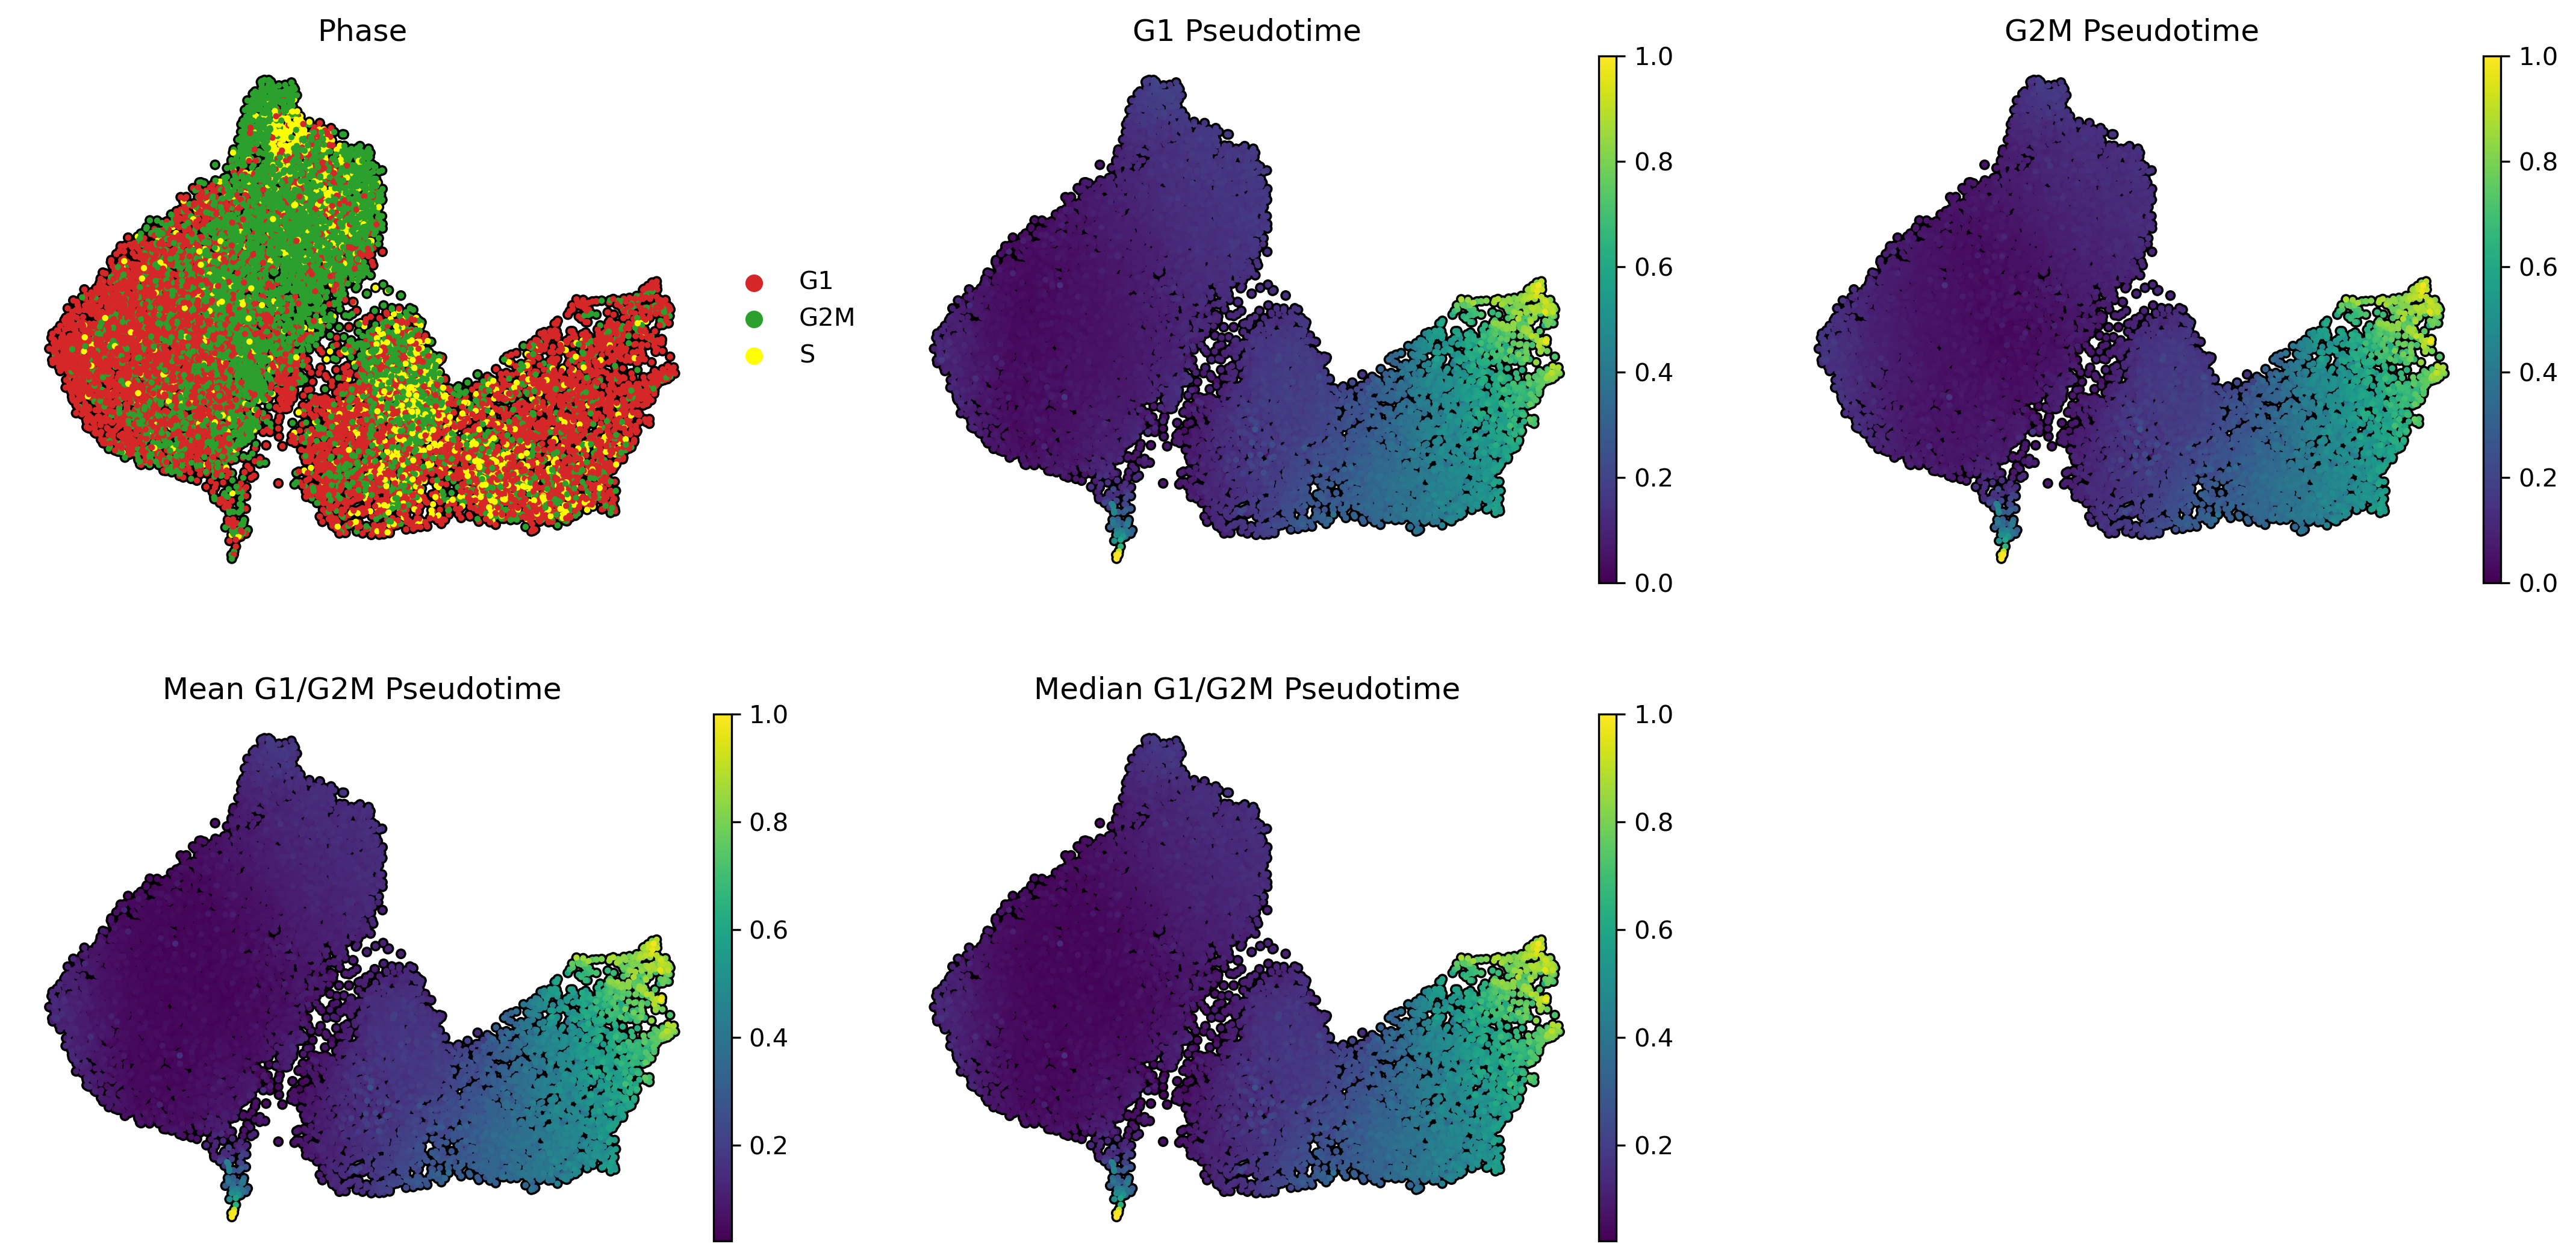

In [141]:
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep='X_diffmap')

obs_key = 'phase' # 'assigned_condition'

for phase in ['G1', 'G2M']:
    
    cell_id, root_idx = find_closest_cell(
        adata,
        obs_key=obs_key,
        value=phase,
        obsm_key='X_pca_harmony',
        dataset='Control',
    )
    
    print(f"\n{phase}: {cell_id=} {root_idx=}\n")
    
     # set root and run pseudotime
    adata.uns["iroot"] = root_idx
    sc.tl.dpt(adata, n_branchings=0)#, allow_kendall_tau_shift=True)

    adata.obs[f'{phase}_pseudotime'] = adata.obs['dpt_pseudotime']
    # adata.obs[f'{phase}_order'] = adata.obs['dpt_order']
    
    
# include the mean of each
adata.obs['mean_pseudotime'] = adata.obs[['G1_pseudotime', 'G2M_pseudotime']].mean(axis=1)
adata.obs['med_pseudotime'] = adata.obs[['G1_pseudotime', 'G2M_pseudotime']].median(axis=1)
# adata.obs['mean_order'] = adata.obs[['G1_order', 'G2M_order']].mean(axis=1)    
    
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 4

sc.pl.umap(
    adata, 
    color=['phase', 'G1_pseudotime', 'G2M_pseudotime', 'mean_pseudotime', 'med_pseudotime'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    title=['Phase', 'G1 Pseudotime', 'G2M Pseudotime', 'Mean G1/G2M Pseudotime', 'Median G1/G2M Pseudotime'],
    frameon=False,
)

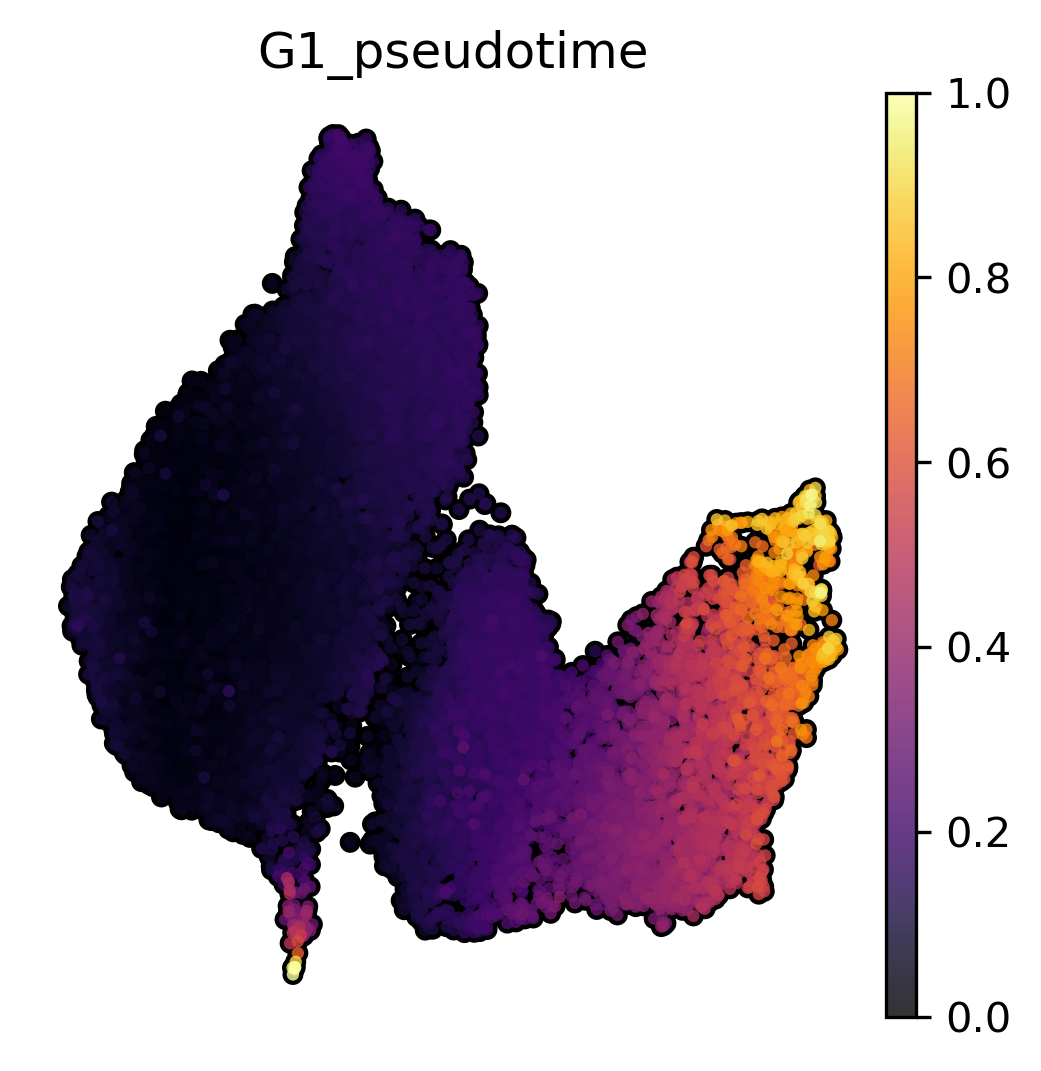

In [150]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4


sc.pl.umap(
    adata,
    color='G1_pseudotime',
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    title="G1_pseudotime",
    cmap='inferno',
    # palette=cluster_colors,
    # colorbar_loc=None,
)

In [145]:
df = adata.obs.copy()

which_dpt = 'G1_pseudotime'

# add genes
df = pd.concat([df, adata.to_df()], axis=1)

# filter data
df = df[np.isfinite(df[which_dpt])].copy()
df['dpt_rank'] = df[which_dpt].rank()

results = []
for gene in tqdm(adata.var_names, desc="Computing Pearson Correlation"):
    corr, pval = scipy.stats.pearsonr(df[which_dpt], df[gene])
    results.append({
        'gene' : gene,
        'corr' : corr,
        'pval' : pval,
    })

results = pd.DataFrame(results)
results['adj_p_value'] = multipletests(results['pval'], method='fdr_bh')[1]
results = results.sort_values('corr', ascending=False)

print("="*20 + " Positive Correlation " + "="*20)
print(results.head().to_string(index=False))
print()
print("="*20 + " Negative Correlation " + "="*20)
print(results.tail().to_string(index=False))

Computing Pearson Correlation: 100%|██████████| 25042/25042 [00:08<00:00, 2853.41it/s]

==================== Positive Correlation ====================
           gene     corr  pval  adj_p_value
ENSG00000274213 0.580363   0.0          0.0
          MYOD1 0.577304   0.0          0.0
          HDAC9 0.576279   0.0          0.0
       PPP1R15A 0.570307   0.0          0.0
           ABL2 0.507220   0.0          0.0

==================== Negative Correlation ====================
  gene      corr  pval  adj_p_value
 UBA52 -0.610552   0.0          0.0
RPL27A -0.617505   0.0          0.0
 RPL28 -0.633442   0.0          0.0
 RPS11 -0.636454   0.0          0.0
 RPLP1 -0.655584   0.0          0.0


In [146]:
# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='gene')

# filter sig DEGs for named protein-coding genes
pdf = pd.merge(results, gdf, how='left', on='gene')

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['gene'].str.startswith(('ENSG', 'MT-', 'RP'))]#, 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['mt']]

pdf.head()

,gene,corr,pval,adj_p_value,gene_type,mt,ribo
1,MYOD1,0.577304,0.0,0.0,protein_coding,False,False
2,HDAC9,0.576279,0.0,0.0,protein_coding,False,False
3,PPP1R15A,0.570307,0.0,0.0,protein_coding,False,False
4,ABL2,0.507220,0.0,0.0,protein_coding,False,False
5,RSRC2,0.503628,0.0,0.0,protein_coding,False,False


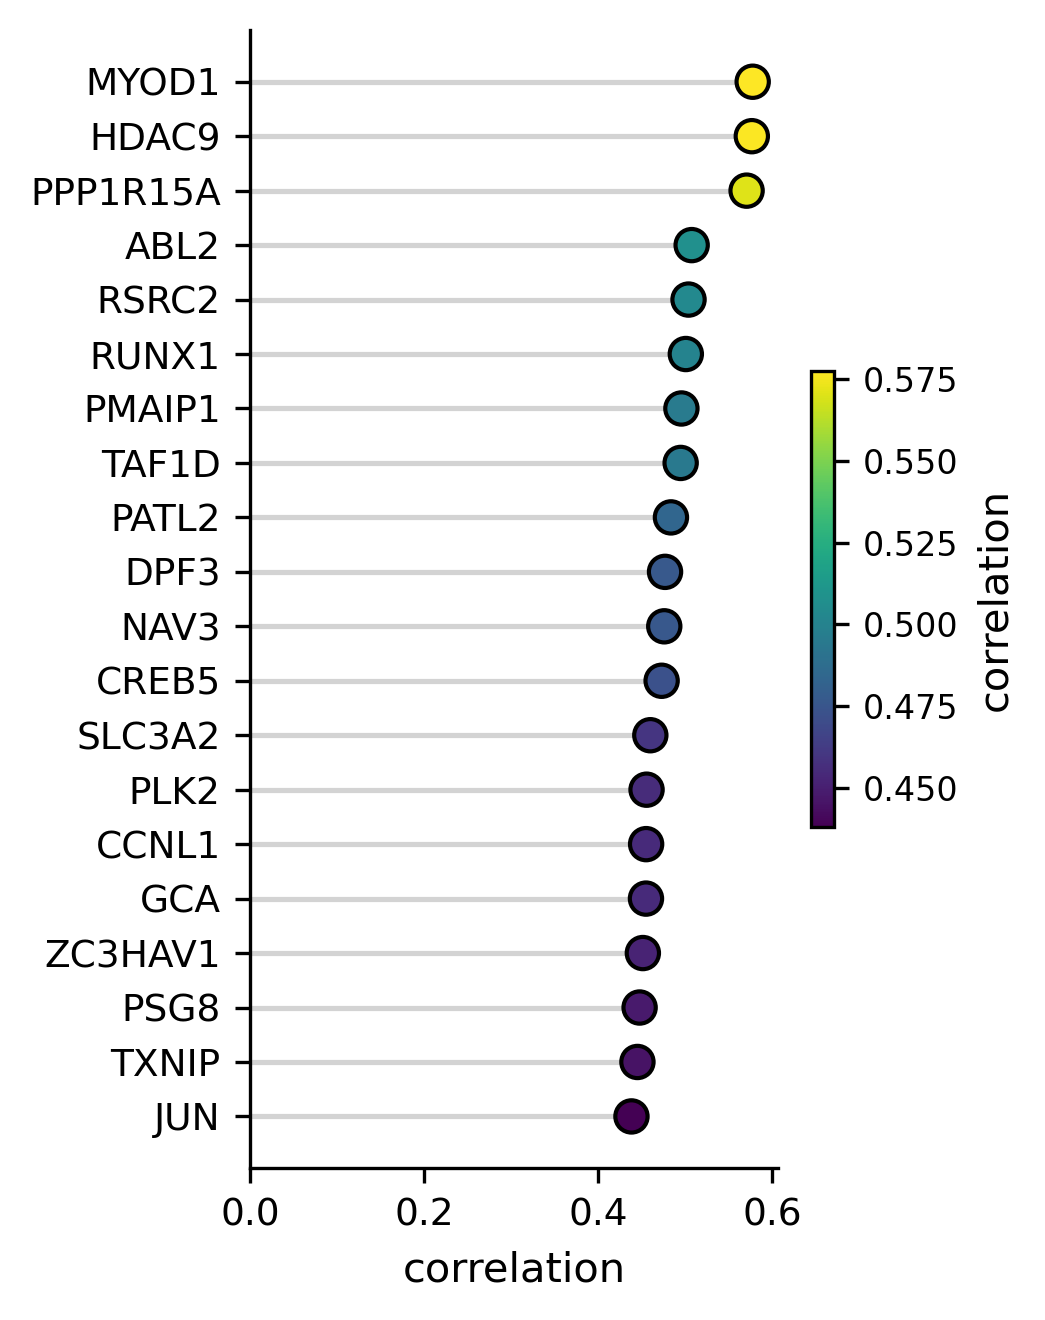

In [147]:
top_n = 20
top = pdf.nlargest(top_n, 'corr').copy()
# top = results.nlargest(top_n, 'corr').copy()
top = top.sort_values("corr")  # ensure genes are in order from low to high

plt.figure(figsize=(3.5, 4.5))
ax = plt.gca()

# Draw lines from y-axis to each dot (baseline = 0)
for i, (gene, corr) in enumerate(zip(top['gene'], top['corr'])):
    ax.hlines(
        y=i,
        xmin=0,
        xmax=corr,
        color='lightgray',
        linewidth=1.25,
        zorder=0,
    )

# Draw the dots
scatter = ax.scatter(
    top['corr'],
    range(len(top)),
    c=top['corr'],
    cmap='viridis',
    edgecolor='black',
    s=60,
    zorder=3,
)

# Format axes
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['gene'], fontsize=9)
ax.set_xlabel("correlation")
ax.set_ylabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='x', labelsize=9)
ax.set_xlim(0, top['corr'].max() * 1.05)

# Optional colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.4,)
cbar.set_label("correlation")
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

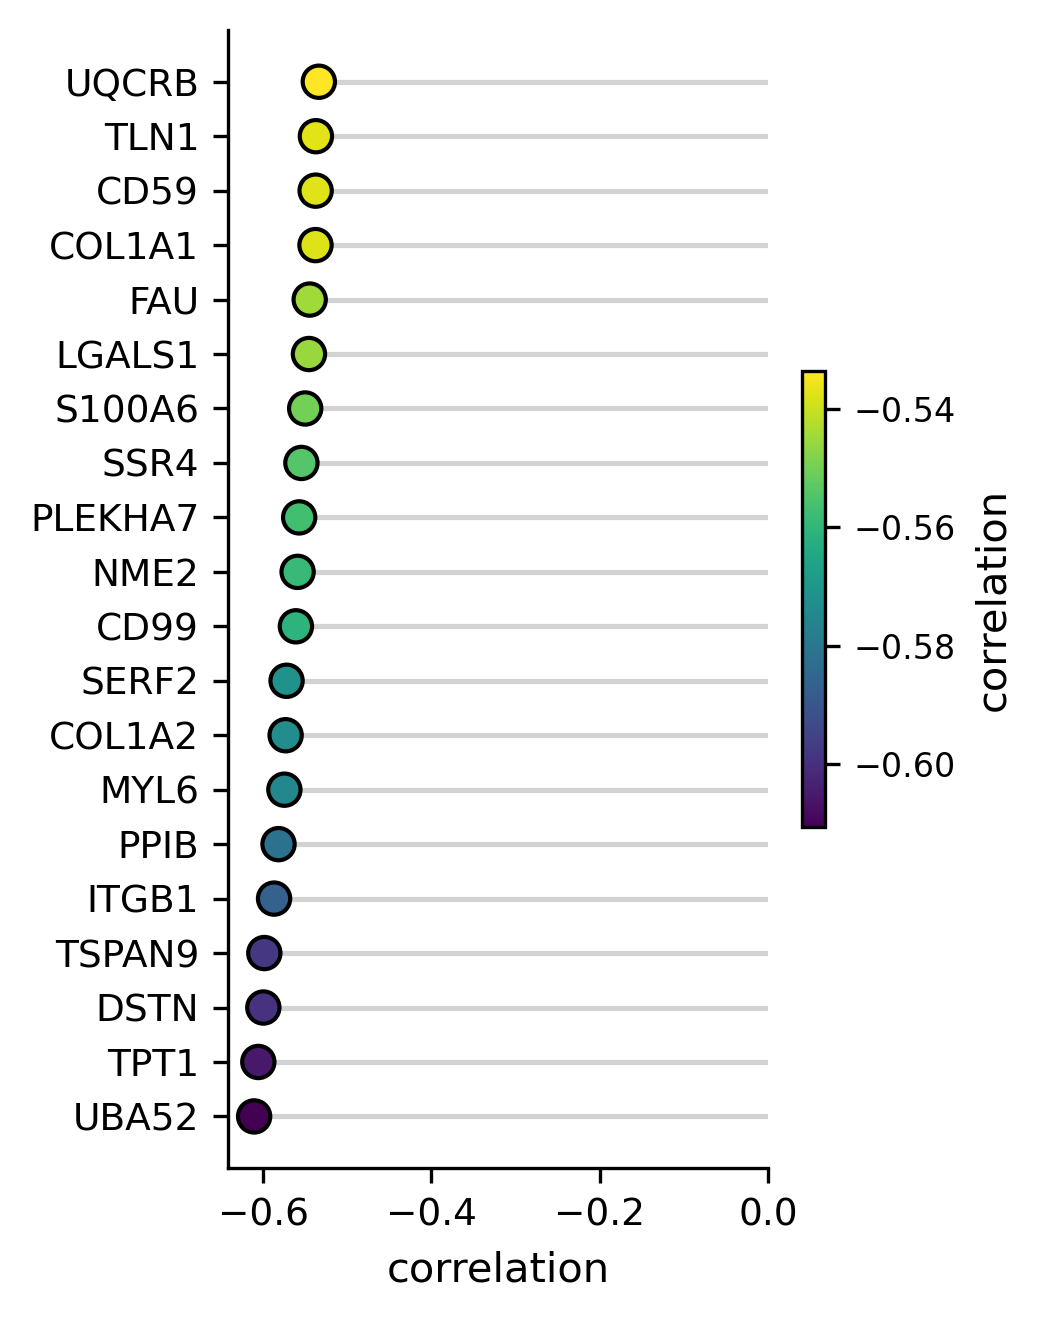

In [151]:
top_n = 20
top = pdf.nsmallest(top_n, 'corr').copy()
top = top.sort_values("corr")  # ensure genes are in order from most negative to less negative

plt.figure(figsize=(3.5, 4.5))
ax = plt.gca()

# Draw lines from y-axis to each dot (baseline = 0)
for i, (gene, corr) in enumerate(zip(top['gene'], top['corr'])):
    ax.hlines(
        y=i,
        xmin=0,
        xmax=corr,
        color='lightgray',
        linewidth=1.25,
        zorder=0,
    )

# Draw the dots
scatter = ax.scatter(
    top['corr'],
    range(len(top)),
    c=top['corr'],
    cmap='viridis',
    edgecolor='black',
    s=60,
    zorder=3,
)

# Format axes
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['gene'], fontsize=9)
ax.set_xlabel("correlation")
ax.set_ylabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='x', labelsize=9)
ax.set_xlim(top['corr'].min() * 1.05, 0)

# Optional colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.4)
cbar.set_label("correlation")
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# sc.tl.diffmap(adata)
# sc.pp.neighbors(adata, use_rep='X_diffmap')


# cell_id, root_idx = find_closest_cell(
#     hyb_adata,
#     obs_key='phase',
#     value='G1',
#     obsm_key='X_pca_harmony',
# )

# hyb_adata.uns['iroot'] = root_idx

# sc.tl.dpt(hyb_adata, n_branchings=0)

# sc.pl.umap(
#     hyb_adata,
#     color='dpt_pseudotime',
#     size=35,
#     add_outline=True,
#     na_in_legend=False,
#     outline_color=('k', 'k'),
#     frameon=False,
# )

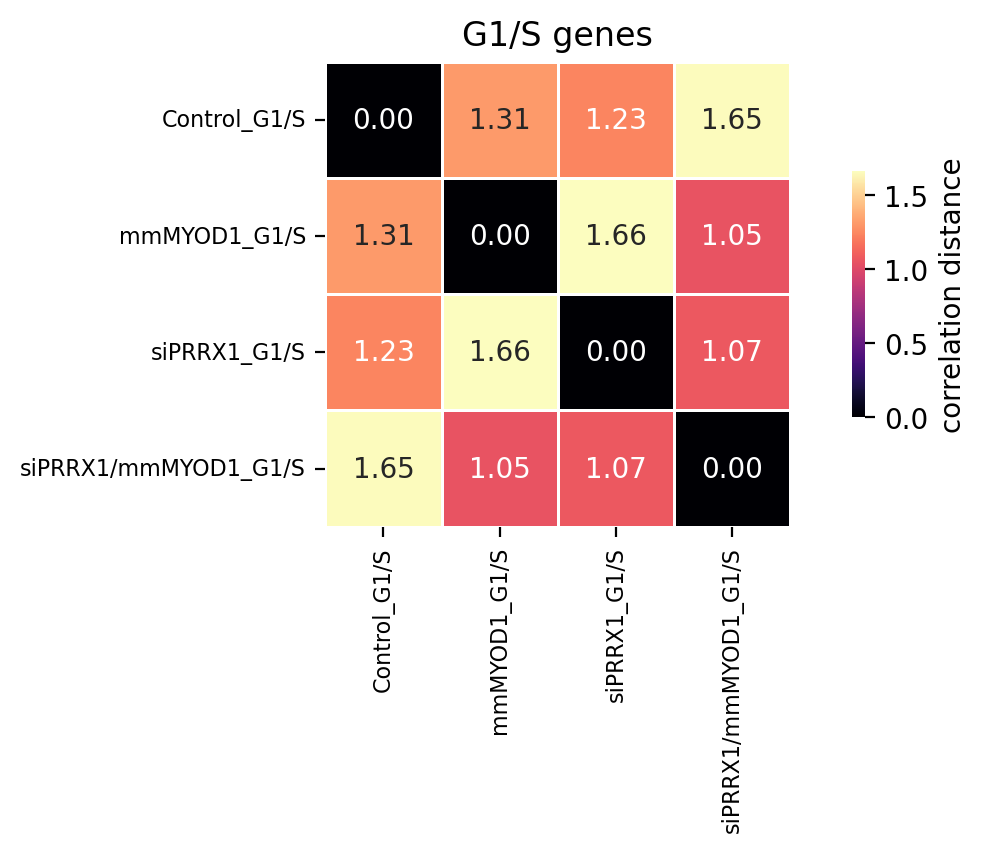

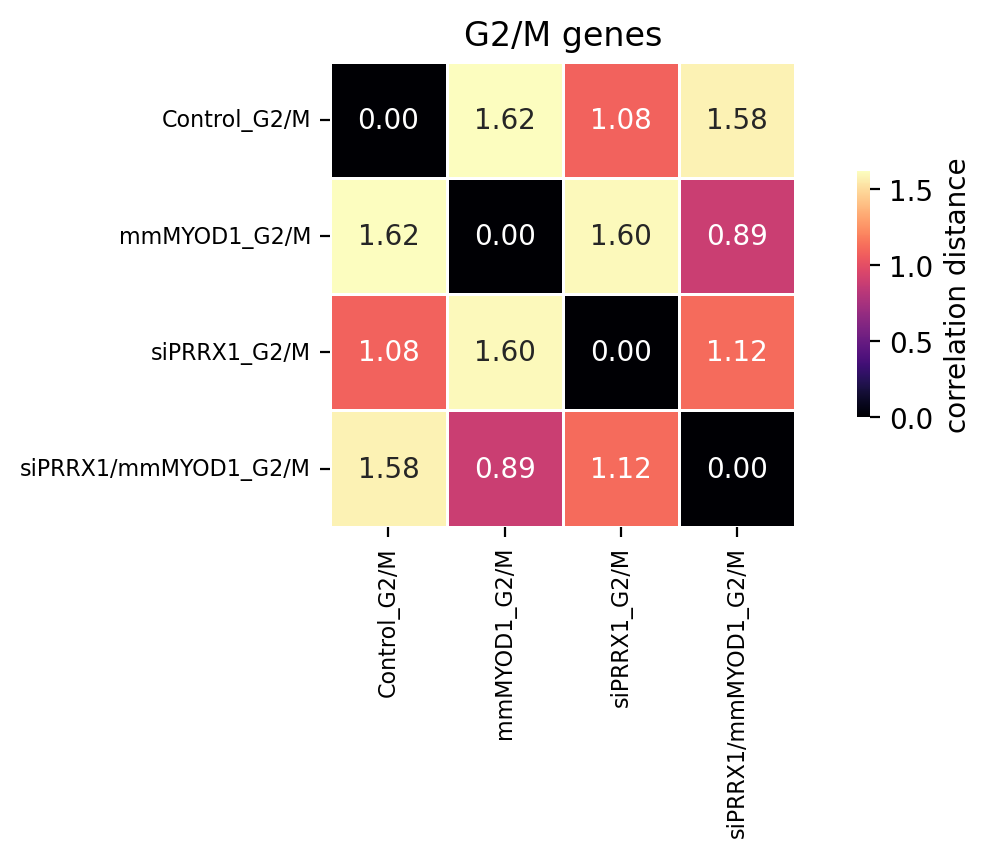

In [77]:
# def corr_distance_heatmap(X, labels, metric, title="", dpi=200, figsize=(4, 4)):
#     dist = squareform(pdist(X, metric=metric))
#     dist_df = pd.DataFrame(dist, index=labels, columns=labels)

#     plt.rcParams['figure.dpi'] = dpi
#     plt.figure(figsize=figsize)
    
#     sns.heatmap(
#         dist_df,
#         cmap="magma",
#         square=True,
#         annot=True,
#         fmt=".2f",
#         lw=0.5,
#         cbar_kws={'label':f'{metric} distance', 'shrink': 0.4, 'pad': 0.1},
#     )
    
#     plt.xlabel("")
#     plt.ylabel("")
#     plt.xticks(rotation=90, fontsize=8)
#     plt.yticks(rotation=0, fontsize=8)
    
#     plt.title(title)
#     plt.show()

    
    
# metric = 'correlation'

# # G1/S
# labels_G1S = gdata.obs.loc[G1S_cells, "condition_by_phase_group"]
# corr_distance_heatmap(
#     X__G1S_z,
#     # X_G1S,
#     labels_G1S,
#     metric=metric,
#     title="G1/S genes",
# )

# # G2/M
# labels_G2M = gdata.obs.loc[G2M_cells, "condition_by_phase_group"]
# corr_distance_heatmap(
#     X_G2M_z,
#     # X_G2M,
#     labels_G2M,
#     metric=metric,
#     title="G2/M genes",
# )

In [ ]:
# def plot_distance_heatmap(
#     X,
#     labels,
#     metric="euclidean",
#     title="change me",
#     ax=None,
#     figsize=(7.5, 7.5),
#     cmap='bwr',
#     column_filter=None,
#     row_filter=None,
#     norm=None,
#     column_rank=False,
#     row_rank=False,
# ):
#     """
#     Compute and plot a heatmap of pairwise distances.

#     Parameters:
#     - X: dense or sparse expression matrix (cells x genes)
#     - labels: list of labels for each cell
#     - metric: distance metric for pdist (default: "euclidean")
#     - title: heatmap title
#     - ax: optional matplotlib axis object
#     - figsize: tuple (width, height) in inches
#     - cmap: colormap for heatmap
#     - column_filter: list of label values to include in the columns of distance matrix
#     - row_filter: list of label values to include in the rows of distance matrix
#     - norm: can be (1 for rows, 0 for columns, or None)
#     - column_rank: if true, return values as column ranks
#     - row_rank: if true, return values as row ranks
#     """
#     X_dense = X.toarray() if not isinstance(X, np.ndarray) else X
#     distance_matrix = squareform(pdist(X_dense, metric=metric))
#     distance_df = pd.DataFrame(distance_matrix, index=labels, columns=labels)

#     if ax is None:
#         plt.rcParams['figure.dpi'] = 300
#         fig, ax = plt.subplots(figsize=figsize)

#     if not column_filter is None:
#         distance_df = distance_df[column_filter]

#     if not row_filter is None:
#         distance_df = distance_df.loc[row_filter]

#     if norm == 1:
#         # Z-score normalization across rows
#         distance_df = distance_df.sub(distance_df.mean(axis=1), axis=0)
#         distance_df = distance_df.div(distance_df.std(axis=1), axis=0)
#     elif norm == 0:
#         # Z-score normalization across columns
#         distance_df = distance_df.sub(distance_df.mean(axis=0), axis=1)
#         distance_df = distance_df.div(distance_df.std(axis=0), axis=1)
#     elif norm is None:
#         # No normalization
#         distance_df = distance_df.copy()
#     else:
#         raise ValueError("norm must be 1 (rows), 0 (columns), or None")

#     if column_rank:
#         distance_df = distance_df.rank(axis=1)
#     if row_rank:
#         distance_df = distance_df.rank(axis=0)

#     sns.heatmap(
#         distance_df,
#         cmap=cmap,
#         square=True,
#         annot=True,
#         fmt=".2f",
#         lw=0.5,
#         cbar_kws={'label': f'{metric} distance', 'shrink': 0.4, 'pad': 0.1},
#         ax=ax,
#     )

#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_title(title)
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
#     ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

#     if ax is None:
#         plt.tight_layout()
#         plt.show()
        
        
        
# X = cdata.X.copy()

# # Compute Z score for genes
# X_z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)

# labels = cdata.obs['condition_by_phase_group'].tolist()

# metrics = [
#     "euclidean",
#     # "cosine",
#     "correlation",
# ]

# n = len(metrics)
# plot_height = 8

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = (plot_height * n), plot_height
# fig, axes = plt.subplots(1, n)

# for i, metric in enumerate(metrics):
#     plot_distance_heatmap(
#         X_z, 
#         # X,
#         labels, 
#         metric=metric, 
#         title=f'Cell Cycle Genes {metric.title()} Distances', 
#         ax=axes[i],
#         # cmap='bwr',
#         cmap='copper_r',
#         # norm=0,
#     )

# plt.tight_layout()